<h2 style = 'text-align: center;'>Loading the Data</h2>

In [12]:
#! pip install -q kaggle

from google.colab import files

files.upload()

Saving kaggle (1).json to kaggle (1) (1).json


{'kaggle (1) (1).json': b'{"username":"shripras11","key":"522dd72da8c6d93bb7f3ce2b1a4b31dd"}'}

In [13]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub

cur_token = 'KGAT_d3fc63f837edb1da25d524b0972a1709'

kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [14]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

isic_2024_challenge_path = kagglehub.competition_download('isic-2024-challenge')

print('Data source import complete.')


Data source import complete.


In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os #for loading in data
import h5py #for reading image data in .hdf5 format
import matplotlib.pyplot as plt #for plotting purposes
from PIL import Image #for visualizing image data
import io #also for image data
import seaborn as sns #for plotting purposes as well
from sklearn.linear_model import LogisticRegression #for logreg
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict #for cross val
from sklearn.pipeline import Pipeline #for pipeline implementation
from sklearn.preprocessing import StandardScaler #for standard scaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder #for one hot encoding
from sklearn.metrics import ( #for performance metrics
    classification_report, roc_auc_score, confusion_matrix,
    average_precision_score, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay)
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.model_selection import train_test_split #to split train into train, val, test


'''
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(filenames)
'''

#this loop won't terminate -- something abt it is just too expensive -- CPU at 100%

"\nfor dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(filenames)\n"

In [14]:
#ROOT_DIR = "/kaggle/input/isic-2024-challenge"
#TRAIN_DIR = f'{ROOT_DIR}/train-image/image'

#train_df = pd.read_csv('/kaggle/input/isic-2024-challenge/train-metadata.csv')
#test_df = pd.read_csv('/kaggle/input/isic-2024-challenge/test-metadata.csv')
train_data = pd.read_csv(f'{isic_2024_challenge_path}/train-metadata.csv')
test_data = pd.read_csv(f'{isic_2024_challenge_path}/test-metadata.csv')

#train_images = h5py.File('/kaggle/input/isic-2024-challenge/train-image.hdf5', 'r')
#test_images = h5py.File('/kaggle/input/isic-2024-challenge/test-image.hdf5', 'r')
train_images = h5py.File(f'{isic_2024_challenge_path}/train-image.hdf5', 'r')
test_images = h5py.File(f'{isic_2024_challenge_path}/test-image.hdf5', 'r')

print(f"The number of samples in train_df is {len(train_data)}")
print(f"The number of samples in test_df is {len(test_data)}")
print(f"The number of samples in train_images is {len(train_images)}")
print(f"The number of samples in test_images is {len(test_images)}")

/tmp/ipykernel_2519/1775746101.py:6: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv(f'{isic_2024_challenge_path}/train-metadata.csv')


The number of samples in train_df is 401059
The number of samples in test_df is 3
The number of samples in train_images is 401059
The number of samples in test_images is 3


In [19]:
#now what do the keys of the h5py files look like?

print(f"Sample keys: {list(train_images.keys())[:5]}")

Sample keys: ['ISIC_0015670', 'ISIC_0015845', 'ISIC_0015864', 'ISIC_0015902', 'ISIC_0024200']


In [16]:
#now the problem is that we don't really have validation or even train data (3 samples of train data isn't enough)
#but since we have sooooo many values in train, let's just split that using random_state 42, 70-15-15 split for train-val-test

#split off test first -- 30 test (will be split again into test and val) and 70 train
train_df, temp = train_test_split(
    train_data,
    test_size=0.30,
    stratify=train_data['target'],
    random_state=42
)

#then split test into val and test (15 each so 50 of the initial 30)
val_df, test_df = train_test_split(
    temp,
    test_size=0.50,
    stratify=temp['target'],
    random_state=42
)

print(f"Train : {train_df.shape[0]} rows, {train_df['target'].sum()} malignant")
print(f"Val   : {val_df.shape[0]} rows, {val_df['target'].sum()} malignant")
print(f"Test  : {test_df.shape[0]} rows, {test_df['target'].sum()} malignant")

#also make sure to do the same to train_images as well?
train_ids = train_df['isic_id'].tolist()
val_ids   = val_df['isic_id'].tolist()
test_ids  = test_df['isic_id'].tolist()

Train : 280741 rows, 275 malignant
Val   : 60159 rows, 59 malignant
Test  : 60159 rows, 59 malignant


<h2 style = 'text-align: center;'>Exploratory Data Analysis</h2>

<h3 style = 'text-align: left;'>Visualizing the Data</h3>

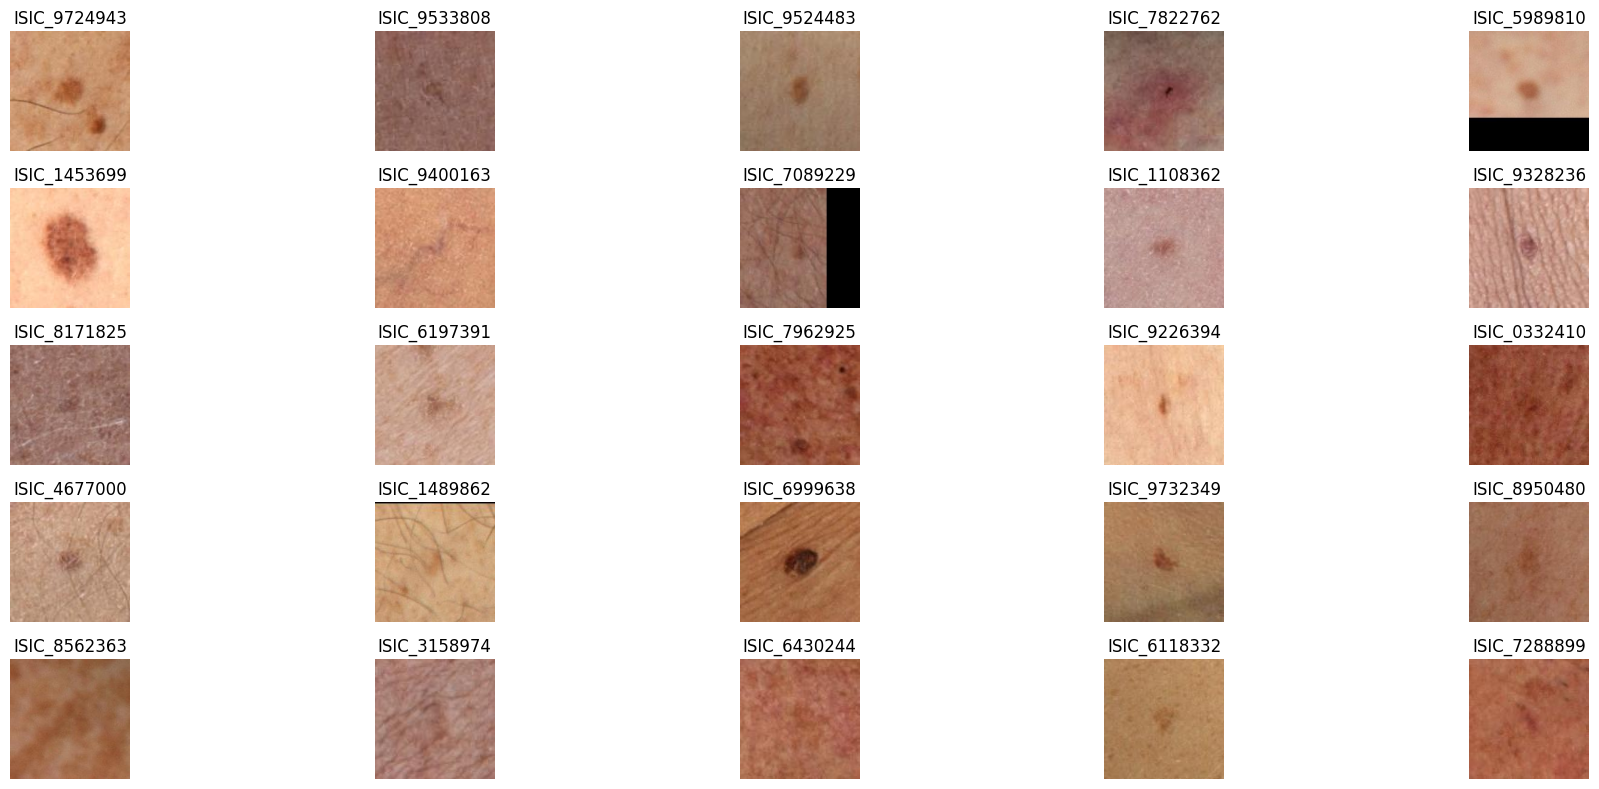

In [22]:
#plotting some of the images just to get a visualization
#get an idea of how the images look

fig, axes = plt.subplots(5,5, figsize = (20,8))
axes = axes.flatten()

for i, key in enumerate(train_ids[:25]):
    img_bytes = np.array(train_images[key])
    img = Image.open(io.BytesIO(img_bytes.tobytes()))
    axes[i].imshow(img)
    axes[i].set_title(key)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

<h3>Looking Deeper at the Data:</h3>

<h4>Columns in only the train data:</h4>

* **target**: Binary class
    * 0: Benign
    * 1: Malignant
* **lesion_id**: Unique lesion identifier
    * present in lesions that were *manually tagged* as a lesion of interest
* **iddx_full**: fully classified lesion diagnosis
* **iddx_1**: first level lesion diagnosis
* **iddx_2**: second level lesion diagnosis
* **iddx_3**: third level lesion diagnosis
* **iddx_4**: fourth level lesion diagnosis
* **iddx_5**: fifth level lesion diagnosis
* **mel_mitotic_index**: mitotic index of invasive malignant melanomas
* **mel_thick_mm**: thickness in depth of melanoma invasion
* **tbp_lv_dnn_lesion_confidence**: lesion confidence score
    * (0-110 scale)

<h4>Columns in both train and test data:</h4>

* **isic_id**: unique case identifier
* **patient_id**: unique patient identifier
* **age_approx**: approximate age of patient at time of imaging
* **sex**: sex of the person
* **anatom_site_general** location of the lesion on the patient's body
* **clin_size_long_diam_mm**: maximum diameter of the lesion (in mm)
* **image_type**: structured field of the ISIC Archive for image type
* **tbp_tile_type**: lighting modality of the 3D TBP source image
* **tbp_lv_A**: A inside lesion
* **tbp_lv_Aex**: A outside lesion
* **tbp_lv_B**: B inside lesion
* **tbp_lv_Bext**: B outside lesion
* **tbp_lv_C**: Chroma inside lesion
* **tbp_lv_Cext**: Chrome outside lesion
* **tbp_lv_H**: Hue inside the lesion; calculated as the angle of A* and B* in LAB* color space. Typical values range from 25 (red) to 75 (brown).
* **tbp_lv_Hext**: Hue outside lesion
* **tbp_lv_L**: L inside lesion
* **tbp_lv_Lext**: L outside lesion
* **tbp_lv_areaMM2**: area of lesion (mm^2)
* **tbp_lv_area_perim_ratio**: Border jaggedness, the ratio between lesions perimeter and area. Circular lesions will have low values; irregular shaped lesions will have higher values. Values range 0-10.
* **tbp_lv_color_std_mean**: Color irregularity, calculated as the variance of colors within the lesion's boundary.
* **tbp_lv_deltaA**: Average A contrast (inside vs. outside lesion).
* **tbp_lv_deltaB**: Average B contrast (inside vs. outside lesion).
* **tbp_lv_deltaL**: Average L contrast (inside vs. outside lesion).
* **tbp_lv_deltaLBnorm**: Contrast between the lesion and its immediate surrounding skin.
    * Low contrast lesions tend to be faintly visible such as freckles;
    * high contrast lesions tend to be those with darker pigment.
    * Calculated as the average delta LB of the lesion relative to its immediate background in LAB* color space.
    * Typical values range from 5.5 to 25.
* **tbp_lv_eccentricity**: eccentricity
* **tbp_lv_location**: Classification of anatomical location, divides arms & legs to upper & lower; torso into thirds.
* **tbp_lv_location_simple**: classification of anatomical location, simple
* **tbp_lv_minorAxisMM**: smallest lesion diameter
* **tbp_lv_nevi_confidence**: Nevus confidence score
    * (0-100 scale) is a convolutional neural network classifier estimated probability that the lesion is a nevus
    * The neural network was trained on approximately 57,000 lesions that were classified and labeled by a dermatologist.
* **tbp_lv_norm_border**: Border irregularity (0-10 scale); the normalized average of border jaggedness and asymmetry.
* **tbp_lv_norm_color**: Color variation (0-10 scale); the normalized average of color asymmetry and color irregularity.
* **tbp_lv_perimeterMM**: perimeter of lesion (in mm)
* **tbp_lv_radial_color_std_max**: Color asymmetry, a measure of asymmetry of the spatial distribution of color within the lesion.
    * This score is calculated by looking at the average standard deviation in LAB* color space within concentric rings originating from the lesion center.
    * Values range 0-10.
* **tbp_lv_stdL**: Standard deviation of L inside lesion.
* **tbp_lv_stdLExt**: Standard deviation of L outside lesion.
* **tbp_lv_symm_2axis**: Border asymmetry; a measure of asymmetry of the lesion's contour about an axis perpendicular to the lesion's most symmetric axis.
    * Lesions with two axes of symmetry will therefore have low scores (more symmetric)
    * lesions with only one or zero axes of symmetry will have higher scores (less symmetric)
    * score is calculated by comparing opposite halves of the lesion contour over many degrees of rotation. The angle where the halves are most similar identifies the principal axis of symmetry, while the second axis of symmetry is perpendicular to the principal axis.
    * Border asymmetry is reported as the asymmetry value about this second axis. Values range 0-10
* **tbp_lv_symm_2axis_angle**: Lesion border asymmetry angle.
* **tbp_lv_x**:	X-coordinate of the lesion on 3D TBP.
* **tbp_lv_y**:	Y-coordinate of the lesion on 3D TBP.
* **tbp_lv_z**:	Z-coordinate of the lesion on 3D TBP.
* **attribution**: Image attribution, synonymous with image source.
* **copyright_license**: Copyright license.



<br>

<h4>Some Observations:</h4>
It appears that iddx_2 through iddx_5 are generally blank if iddx_1 comes back as benign. It's only when iddx_1 is malignant that deeper level scans are done <br> <br>
Similarly, it's only when there's a malignant lesion that mel_mitotic_index and mel_thick_mm are not NaN, again because they measure invasive malignant melanomas, and aren't necessarily relevant to benign ones

In [23]:
#let's look deeper at the training dataset

train_df.head(2)


,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
390115,ISIC_9724943,0,IP_7069393,60.0,male,anterior torso,3.58,TBP tile: close-up,3D: XP,21.045940,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,100.000000
382383,ISIC_9533808,0,IP_2248025,75.0,male,lower extremity,2.69,TBP tile: close-up,3D: white,18.877442,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,98.824513


In [24]:
#let's get the count of how many benign vs malignant

print(f"There are {(train_df['target'] == 0).sum()} benign samples")
print(f"There are {(train_df['target'] == 1).sum()} malignant samples")

#class imbalance


There are 280466 benign samples
There are 275 malignant samples


<h4>What does this mean for us?</h4>

Clearly, we have a **large class imbalance**. Only about 0.1% of samples are malignant, which can make it difficult for any model that we train to detect malignant cases. The model, if not set up correctly, could decide to predict 'benign' for everything without taking too large of a hit in accuracy. <br> <br>

Some preventative measures include:

* **Oversampling**: duplicate/synthesize malignant samples
* **Undersampling**: randomly remove benign samples to balance the classes
* **Class Weights**: have the model penalize mistakes on malignant cases more heavily
    * this one would be the easiest to implement
* **Focal Loss**: a loss function designed for imbalanced datasets
    * this one is good for medical imaging

When training our model, we should keep an eyes on these.

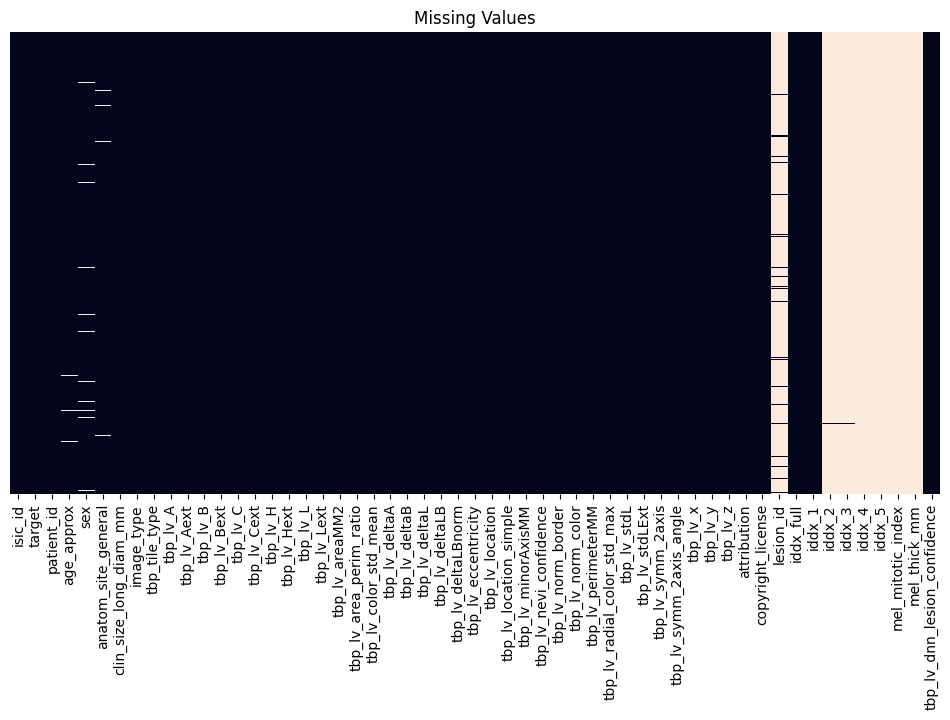

In [25]:
#let's make a heatmap baybeeeee

#first, heatmap for missing values
    #show where NaNs are across my data

plt.figure(figsize = (12,6))
sns.heatmap(train_df.isnull(), yticklabels = False, cbar = False)
plt.title('Missing Values')
plt.show()

In [26]:
#summary of columns with NA values

print(train_df.isna().sum())

isic_id                              0
target                               0
patient_id                           0
age_approx                        1963
sex                               8128
anatom_site_general               4054
clin_size_long_diam_mm               0
image_type                           0
tbp_tile_type                        0
tbp_lv_A                             0
tbp_lv_Aext                          0
tbp_lv_B                             0
tbp_lv_Bext                          0
tbp_lv_C                             0
tbp_lv_Cext                          0
tbp_lv_H                             0
tbp_lv_Hext                          0
tbp_lv_L                             0
tbp_lv_Lext                          0
tbp_lv_areaMM2                       0
tbp_lv_area_perim_ratio              0
tbp_lv_color_std_mean                0
tbp_lv_deltaA                        0
tbp_lv_deltaB                        0
tbp_lv_deltaL                        0
tbp_lv_deltaLB           

In [27]:
#listing columns of concern and how many NaN values in specific columns as seen from our heatmap

print(f"There are \t {(train_df['age_approx'].isna()).sum()} \t\t NaN values out of {len(train_df)} values in column 'age_approx'")
print(f"There are \t {(train_df['sex'].isna()).sum()} \t\t NaN values out of {len(train_df)} values in column 'sex'")
print(f"There are \t {(train_df['anatom_site_general'].isna()).sum()} \t\t NaN values out of {len(train_df)} values in column 'anatom_site_general'")
print(f"There are \t {(train_df['lesion_id'].isna()).sum()} \t NaN values out of {len(train_df)} values in column 'lesion_id'")
print(f"There are \t {(train_df['iddx_2'].isna()).sum()} \t NaN values out of {len(train_df)} values in column 'iddx_2'")
print(f"There are \t {(train_df['iddx_3'].isna()).sum()} \t NaN values out of {len(train_df)} values in column 'iddx_3'")
print(f"There are \t {(train_df['iddx_4'].isna()).sum()} \t NaN values out of {len(train_df)} values in column 'iddx_4'")
print(f"There are \t {(train_df['iddx_5'].isna()).sum()} \t NaN values out of {len(train_df)} values in column 'iddx_5'")
print(f"There are \t {(train_df['mel_mitotic_index'].isna()).sum()} \t NaN values out of {len(train_df)} values in column 'mel_mitotic_index'")
print(f"There are \t {(train_df['mel_thick_mm'].isna()).sum()} \t NaN values out of {len(train_df)} values in column 'mel_thick_mm'")


There are 	 1963 		 NaN values out of 280741 values in column 'age_approx'
There are 	 8128 		 NaN values out of 280741 values in column 'sex'
There are 	 4054 		 NaN values out of 280741 values in column 'anatom_site_general'
There are 	 265209 	 NaN values out of 280741 values in column 'lesion_id'
There are 	 279983 	 NaN values out of 280741 values in column 'iddx_2'
There are 	 279986 	 NaN values out of 280741 values in column 'iddx_3'
There are 	 280361 	 NaN values out of 280741 values in column 'iddx_4'
There are 	 280740 	 NaN values out of 280741 values in column 'iddx_5'
There are 	 280706 	 NaN values out of 280741 values in column 'mel_mitotic_index'
There are 	 280700 	 NaN values out of 280741 values in column 'mel_thick_mm'


<h4>What causes these NaN values?</h4>

We mentioned earlier that there were more NaN values than values of meaning in our iddx_2, iddx_3, iddx_4, and iddx_5 columns, as these deeper level scans are only done when a malignant lesion is detected in iddx_1. A similar reasoning can be used to describe NaN values in mel_mitotic_index, mel_thick_mm, and lesion_id, as these require the presence of a malignant lesion. <br><br>
The NaN values in column sex and age_approx could be attributed to patients not providing that information, or missing data in records. <br><br>
The NaN values in column anatom_site_general could be attributed to the physician not documenting this information or the location of the lesion being unclear <br><br>

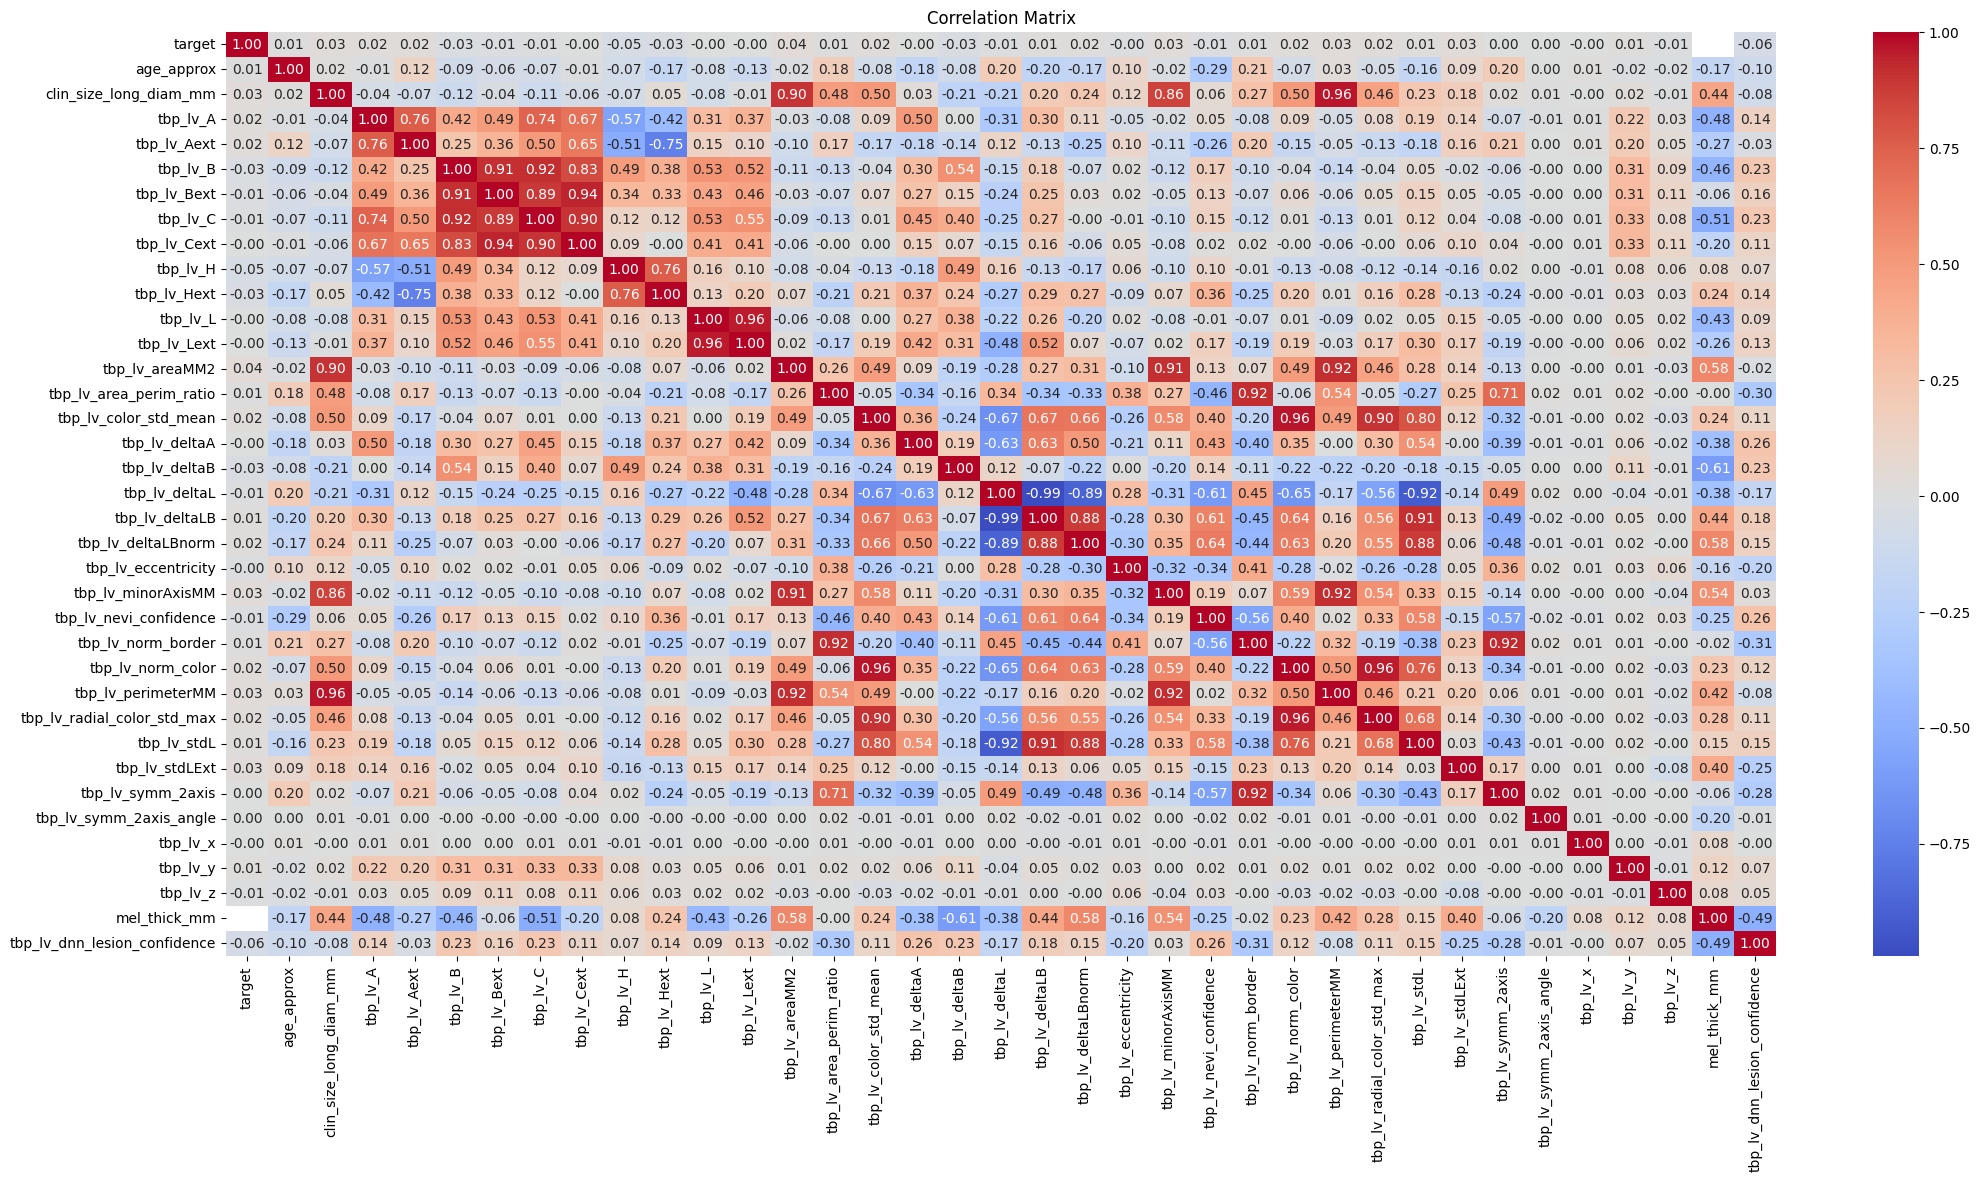

In [28]:
#now heatmap for numeric columns


plt.figure(figsize = (25,12))
sns.heatmap(train_df.select_dtypes(include = np.number).corr(), annot = True, fmt = '.2f', cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

<h4>Interpretation:</h4>

The variables with high levels of correlation are those expected to be highly correlated, for lack of a better description. For instance, the variables tbp_lv_A, tbp_lv_Aex, tbp_lv_B, tbp_lv_Bext, tbp_lv_C, tbp_lv_Cext have varying higher levels of correlation, which is understandable as they all either measure the same thing but inside or outside of the lesion, or a largely similar measure (eg: hue vs. chroma). Additionally, we can see that variables related to measures of the lesion are largely correlated, which is also reasonable to assume.

<h4>What Does This Mean?</h4>

In terms of training a model to be able to detect these differences, we should attempt to see if including one highly correlated variable and excluding another can account for the information that both would provide together. In other words, we want to keep a minimal amount of relevant features in our model without overfitting or losing important distinguising information

<h2 style = 'text-align: center;'>Modeling</h2>

<h3 style = 'text-align: left;'>Logistic Regression: Tabular Data Only</h3>

<h4 style = 'text-align: left;'>Things we need to take into account:</h4>


* **Class Imbalance**: We have a severe case of class imbalance, with 393 of our entries being malignant and 400666 being benign. To account for this, we'll use class_weight = 'balanced' in our Logistic Regression, which should upweight our malignant cases and keep them from being overridden by our benign cases.
* **Leakage Columns**: Many of our features only become relevant in malignant cases. Thus, we'll drop these columns in order to keep them from artificially inflating performance.
* **Performance Metric**: Accuracy isn't an effective measure of performance here because of our severe class imbalance. We'll instead use ROC-AUC and PR-AUC

In [5]:
#defining a logreg function that we can call on different train_data that we build
#logreg doesn't really benefit from the validation set
#it's more useful when training occurs in epochs (like in neural networks)
#so we'll just evaluate on the test data here

def run_log_reg(df):
  leakage_cols = [
      "lesion_id",
      "iddx_full", "iddx_1", "iddx_2", "iddx_3", "iddx_4", "iddx_5",
      "mel_mitotic_index",
      "mel_thick_mm",
      "tbp_lv_dnn_lesion_confidence"]

  admin_cols = [
      "isic_id", "patient_id",
      "attribution", "copyright_license",
      "image_type",
      "tbp_tile_type"]

  target = "target"
  to_be_dropped = leakage_cols + admin_cols
  drop_cols = [c for c in to_be_dropped if c in df.columns]

  feature_df = df.drop(columns=drop_cols + [target])

  #categorical features
  categorical = [
      "sex",
      "anatom_site_general",
      "tbp_lv_location",
      "tbp_lv_location_simple",
  ]
  cat_cols = [c for c in categorical if c in feature_df.columns]

  #all remaining numeric features
  num_cols = feature_df.select_dtypes(include=["number"]).columns.tolist()

  print(f"We have ({len(num_cols)}):numeric features")
  print(f"We have ({len(cat_cols)}): categorical features")

  X = feature_df
  y = df[target]

  #making pipeline
  numeric_transformer = Pipeline([
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler()),
  ])

  categorical_transformer = Pipeline([
      ("imputer", SimpleImputer(strategy="most_frequent")),
      ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
  ])

  preprocessor = ColumnTransformer([
      ("num", numeric_transformer, num_cols),
      ("cat", categorical_transformer, cat_cols),
  ])

  #logreg
  model = Pipeline([
      ("preprocessor", preprocessor),
      ("clf", LogisticRegression(
          class_weight="balanced",
          max_iter=1000,
          solver="lbfgs",
          C=1.0,
          random_state=42,
      )),
  ])

  #cross val
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

  cv_results = cross_validate(
      model, X, y, cv=cv,
      scoring=["roc_auc", "average_precision", "f1"],
      return_train_score=False,
      n_jobs=-1,
      verbose=1,
  )

  print("\n── Cross-Validation Results ──────────────────────────────────")
  for metric, key in [("ROC-AUC", "roc_auc"), ("PR-AUC (Avg Precision)", "average_precision"), ("F1", "f1")]:
      scores = cv_results[f"test_{key}"]
      print(f"  {metric:<22}: {scores.mean():.4f} ± {scores.std():.4f}  (folds: {np.round(scores, 4)})")


  #final model
  model.fit(X, y)

  y_pred  = model.predict(X)
  y_proba = model.predict_proba(X)[:, 1]

  print("\n── Full Training Set Metrics ─────────────────────────────────")
  print(f"  ROC-AUC   : {roc_auc_score(y, y_proba):.4f}")
  print(f"  PR-AUC    : {average_precision_score(y, y_proba):.4f}")
  print("\nClassification Report (train):")
  print(classification_report(y, y_pred, target_names=["Benign (0)", "Malignant (1)"]))

  return model, cv_results, num_cols, cat_cols, y, y_pred, y_proba



In [41]:
#calling it on our full tabular data only
baseline_logreg, baseline_logreg_cv_results, num_cols, cat_cols, y, y_pred, y_proba = run_log_reg(train_df)

We have (34):numeric features
We have (4): categorical features


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   47.1s finished



── Cross-Validation Results ──────────────────────────────────
  ROC-AUC               : 0.8928 ± 0.0123  (folds: [0.8875 0.8907 0.9154 0.892  0.8783])
  PR-AUC (Avg Precision): 0.0294 ± 0.0122  (folds: [0.0179 0.0297 0.0496 0.0341 0.0158])
  F1                    : 0.0104 ± 0.0005  (folds: [0.01   0.0104 0.0107 0.011  0.0098])

── Full Training Set Metrics ─────────────────────────────────
  ROC-AUC   : 0.9196
  PR-AUC    : 0.0256

Classification Report (train):
               precision    recall  f1-score   support

   Benign (0)       1.00      0.85      0.92    280466
Malignant (1)       0.01      0.82      0.01       275

     accuracy                           0.85    280741
    macro avg       0.50      0.84      0.47    280741
 weighted avg       1.00      0.85      0.92    280741



<h4 style = 'text-align: left;'>What Does All of This Mean?</h4>

* **ROC_AUC**: The model is ranking malignant cases higher than benign ones. 0.8928 suggests that if we randomly picked one malignant and one benign sample, the model ranks the malignant one higher abour 89.28 percent of the time.
* **PR-AUC**: This metric more honestly describes the model's performance. The baseline PR_AUC here would just be our malignancy rate (275/280741) = 0.098%. Our model is achieving a rate of 0.0294 instead, which is slightly better than random, but still pretty low. This means that the model is incorrect the majority of the time it classifies something as malignant. With our severe class imbalance though, this is likely just unavoidable as there just aren't enough malignant cases for the model to learn a tighter decision boundary.
* **Recall vs Precision**: The model has 82% recall on malignant cases, meaning it correctly catches 82% of our 295 malignant samples, which is good as we don't want to miss a malignant case. However, we pay for this high malignant recall in precision, as we have a 1% precision rate on malignant cases, which suggests that, for every 100 cases flagged as malignant, only 1 of them actually is. The model is marking a lot of benign cases as malignant as well, which is likely a direct consequence of class_weight = 'balanced' when fitting our logreg function.
* **Next Steps**: We could add in image features, try a tree based method (XGBoost), or attempt threshold tuning, setting the cutoff to 0.2 instead of 0.5 to see if that improves precision.

In [4]:
#defining a function for feature importance
def feature_importance(model, num_cols, cat_cols):
  ohe_features = (
      model.named_steps["preprocessor"]
      .named_transformers_["cat"]
      .named_steps["ohe"]
      .get_feature_names_out(cat_cols)
      .tolist()
  )
  all_features = num_cols + ohe_features
  coef_df = pd.DataFrame({
      "feature": all_features,
      "coefficient": model.named_steps["clf"].coef_[0],
  }).assign(abs_coef=lambda d: d["coefficient"].abs()).sort_values("abs_coef", ascending=False)

  print("\n── Top 20 Features by |Coefficient| ─────────────────────────")
  print(coef_df.head(20)[["feature", "coefficient"]].to_string(index=False))

  #plotting
  fig2, ax = plt.subplots(figsize=(10, 7))
  top20 = coef_df.head(20).sort_values("coefficient")
  colors = ["#e74c3c" if c > 0 else "#3498db" for c in top20["coefficient"]]
  ax.barh(top20["feature"], top20["coefficient"], color=colors)
  ax.axvline(0, color="black", linewidth=0.8)
  ax.set_xlabel("Logistic Regression Coefficient")
  ax.set_title("Top 20 Feature Coefficients\nRed = increases malignancy risk  |  Blue = decreases")

  plt.show()



── Top 20 Features by |Coefficient| ─────────────────────────
                                feature  coefficient
                            tbp_lv_Cext    10.434873
                     tbp_lv_norm_border     5.549625
                               tbp_lv_C    -5.061004
                tbp_lv_area_perim_ratio    -4.303893
         tbp_lv_location_simple_Unknown    -3.461953
                tbp_lv_location_Unknown    -3.461953
                            tbp_lv_Bext    -3.084967
                      tbp_lv_symm_2axis    -2.501552
                          tbp_lv_deltaB     2.132417
                         tbp_lv_deltaLB    -2.085079
                            tbp_lv_Aext    -2.022652
              tbp_lv_location_Right Arm    -1.996472
    anatom_site_general_posterior torso    -1.918690
                               tbp_lv_H    -1.887088
                               tbp_lv_B    -1.724682
                     tbp_lv_perimeterMM     1.669288
      tbp_lv_location_simple_Torso B

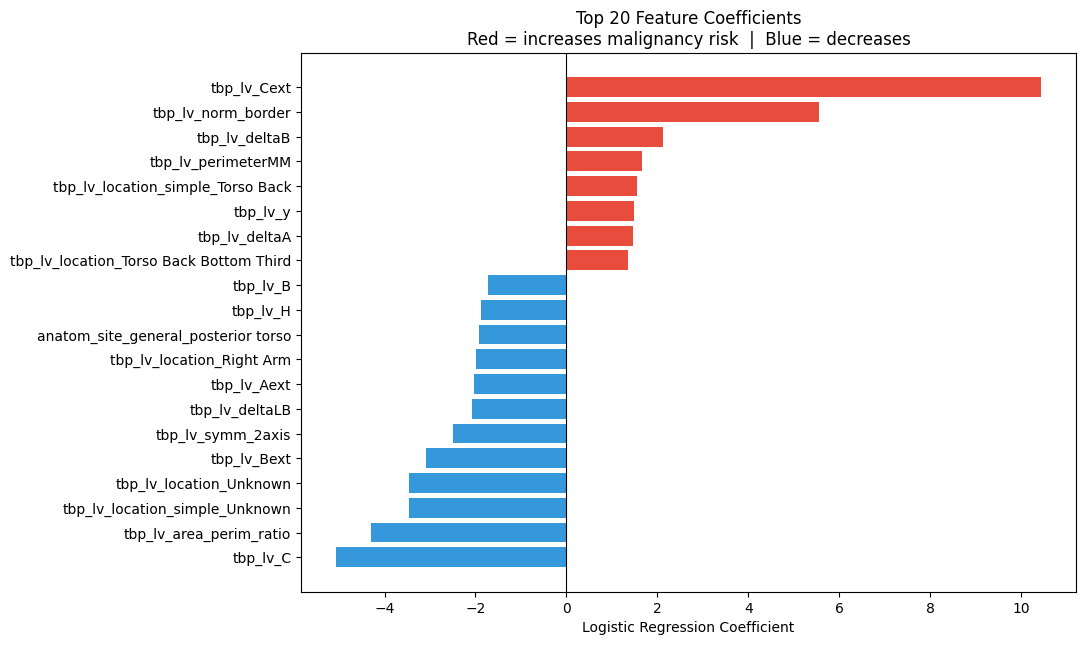

In [43]:
#calling it on our full tabular data
feature_importance(baseline_logreg, num_cols, cat_cols)

In terms of feature importance:

* **tbp_lv_Cext = +10.435**: This is the strongest predictor by far, suggesting that chroma outside of the lesion increases the risk of malignancy. This seems counterintuitive as we'd expect the lesion itself to matter more than chroma outside of the lesion, but it appear the skin surrounding the lesion could reflect inflammatory response or contrast effects in aggressive lesions.
* **tbp_lv_norm_border= +5.550**: This predictor being the second most powerful contributer suggests that higher border irregularity strongly increases the predicted probability of malignancy. Clinically, this is a reasonable observation as how jagged or irregular the border of a lesion appears is included in the ABCDE criteria for melanoma detection (B for border).
* **tbp_lv_C = -5.061**: High chroma inside the lesion also appears to affect the model highly, suggesting that the model is taking into account the contrast between inside and outside the lesion as a key signal.


Saved: logreg_evaluation.png
Saved: logreg_feature_importance.png


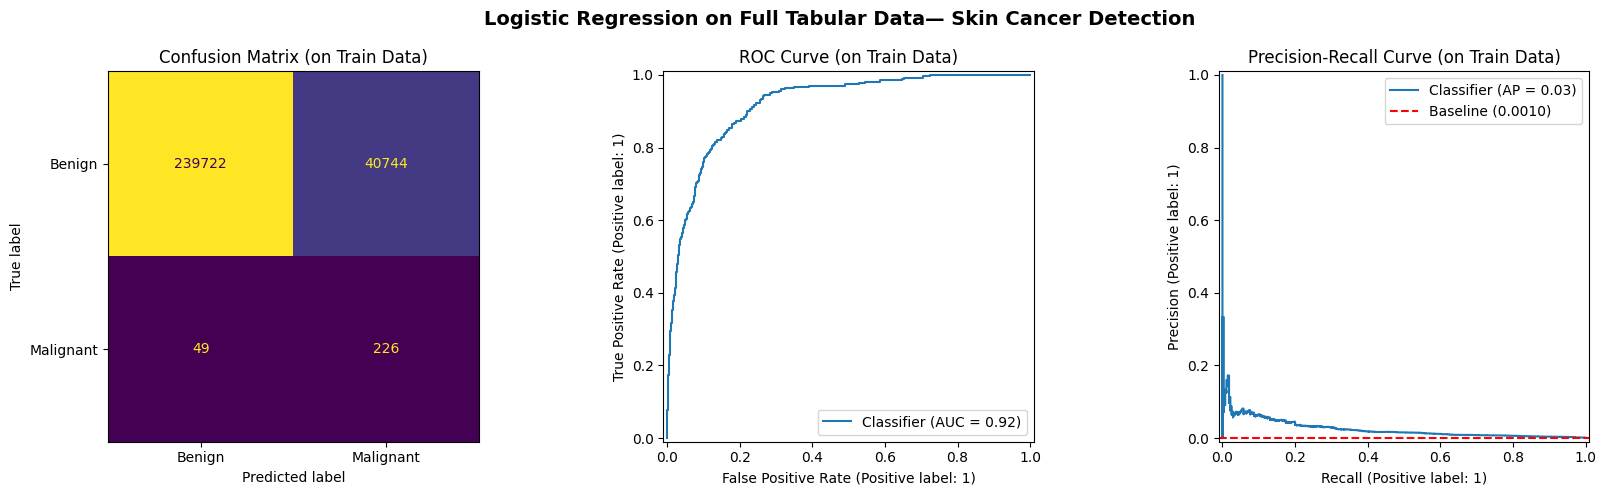

In [44]:
#plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Logistic Regression on Full Tabular Data— Skin Cancer Detection", fontsize=14, fontweight="bold")

#confusion matrix
cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (on Train Data)")

#roc curve
RocCurveDisplay.from_predictions(y, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve (on Train Data)")

#precision recall
PrecisionRecallDisplay.from_predictions(y, y_proba, ax=axes[2])
baseline = y.mean()
axes[2].axhline(baseline, color="red", linestyle="--", label=f"Baseline ({baseline:.4f})")
axes[2].legend()
axes[2].set_title("Precision-Recall Curve (on Train Data)")

plt.tight_layout()
plt.savefig("logreg_evaluation.png", dpi=150, bbox_inches="tight")
print("\nSaved: logreg_evaluation.png")


plt.tight_layout()
plt.savefig("logreg_feature_importance.png", dpi=150, bbox_inches="tight")
print("Saved: logreg_feature_importance.png")


* **Confusion Matrix**: As stated earlier, we have 226 malignant cases accurately classified as malignant, and 49 malignant cases incorrectly classified as benign. Additionally, we have 293722 benign cases correctly classified, and 40744 benign cases incorrectly classified as malignant. This explains our 82% recall for malignant and 85% for benign, as our model is misclassifying many of the benign cases as malignant in an attempt to equally weigh both malignant and benign cases.
* **ROC Curve**: We have an AUC of 0.92, which seems quite good, all things considered. This implies that the model is correctly ranking random malignant cases above benign 92% of the time. The curve hugging the top left corner also suggests good discrimination ability. However, the AUC can be misleading when it comes to imbalanced data, so we should take this curve with a grain of salt.
* **Precision Recall Curve**: This is a more honest metric as compared to to ROC. We have an AP = 0.03, which is incredibly low. Looking at our confusion matrix provides some explanation for this, where we're misclassifying 40744 benign cases and 49 malignant cases. The data is incredibly imbalanced, suggesting that our model gets a high ROC score by being right on the majority class the majority of the time, but the precision-recall curve exposes the poor accuracy of the model.

<h3 style = 'text-align: left;'>Logistic Regression: Tabular and Image Data</h3>

<h4 style = 'text-align: left;'>Things to Keep In Mind:</h4>

We need to extract features from the provided images in order to better fit a model that takes into account our severe class imbalance. To do this, we'll use a Convolutional Neural Network, a CNN.
* **PreTrained CNN (EfficientNet B0)**: First, we will use EfficientNet, which is a family of convulutional neural network models (B0-B7), that achieve higher accuracy while maintaining a relatively small and fast network. It uses 'compound scaling' that uniformly scaled network depth, width, and resolution using a fixed set of scaling coefficients to scale all three of these dimensions in a more balanced manner.
  * *EfficientNet-B0* was primarily trained on the ImageNet-1k dataset, which contains over a million images categorized into 1000 distinct classes. Thus, it already has an idea of how to detect edges, textures, color gradients, and irregular shapes, and should result in a much higher accuracy at a much more efficient rate than any custom trained CNN model we could develop.
* **Combination of EfficientNet-B0 and Custom-Trained CNN**: Still using EfficientNet-B0 as a backbone, we can alter the top layers specifically towards skin lesion patterns, making this neural net more applicable to our data. As mentioned earlier, fitting our own custom CNN trained from scratch could prove meaningless, as we would have to account for our severe class imbalance. Our custom-trained model has the potential to overfit to our 393 positive cases and fail to generalize, or could just choose to predict everything as a negative case--maintaining high overall accuracy--despite class weighting. Thus, we try to find a middle-ground and incorporate the best of both worlds. Thus should keep all the strong pretrained ImageNet features from EfficientNet-B0, adapt the top-layers specifically towards skin lesion patterns, and give us a meaningful improvement over the set baselines of the EfficientNet-B0 and the custom-trained CNN.

**Roadblocks We Ran Into**
* train_data + embedded_features = NOT ENOUGH GPU
  * An immediate issue we ran into was the sheer size of our data. Without any sort of PCA applied, it took about 30 minutes to extract the features using a CNN, resulting in 400k rows, and 1.3k+ features. This then couldn't be fed into our logistic regression function because our data with the embedded features included was simply too large and required too much processing power that we didn't have access to.
* embedded_features_with_PCA_applied + train_data = TOO MUCH RUNTIME
  * To attempt to correct this, we then attempted to do incremental PCA while extracting features, reducing the dimensionality of our data while extracting image features. This led to runtime errors, where our sessions timed out before they could complete.
* train_data_small + embedded_features_small
  * Thus, our next approach was to subset our data, keeping all 393 malignant entries and just using 10,000 of our benign entries. We did two runs, one with IncrementalPCA and one without, just to see if there were any differences in precision in each

<h4 style = 'text-align: left;'>No PCA Applied, train_data_small</h4>

In [17]:
benign = train_df[train_df['target'] == 0].sample(10000, random_state=42)
malignant = train_df[train_df['target'] == 1]
train_df_small = pd.concat([benign, malignant]).reset_index(drop=True)

In [18]:
#so funny story this adds stuff to train_data but then
  #train_data will have its 280k samples
  #AND 1128 additional embedded features columns
#which is good bc we need those
#but unfortunately this makes train_data wayyyyy too big and i can't do anything with it afterwards
  #RAM crashes

#so we'll use a subset

device = 'cuda' if torch.cuda.is_available() else 'cpu'
hdf5_path = f"{isic_2024_challenge_path}/train-image.hdf5"
batch_size = 64

#loading the model up
#could try training a custom CNN trained on our data
#but first we'll try a pretrained backbone
  #this pretrained backbone is trained on photos of dogs, cats, cars, etc and should have info on general visual features
    #edges, textures, shapes
  #should still transfer well
#PRETRAINED BACKBONE
backbone = models.efficientnet_b0(weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1)
backbone.classifier = nn.Identity()
backbone = backbone.to(device)
backbone.eval()

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225])
])

all_ids = train_df_small['isic_id'].tolist()
all_embeddings = []

with h5py.File(hdf5_path, 'r') as f:
  for i in tqdm(range(0, len(all_ids), batch_size), desc = 'Extracting features'):
    batch_ids = all_ids[i : i + batch_size]
    tensors = []
    for isic_id in batch_ids:
      if isic_id in f:
        img = Image.open(io.BytesIO(f[isic_id][()])).convert('RGB')
        tensors.append(transform(img))
      else:
        tensors.append(torch.zeros(3,224,224))
    batch_tensor = torch.stack(tensors).to(device)
    with torch.no_grad():
      emb = backbone(batch_tensor).cpu().numpy()
      all_embeddings.append(emb)

all_embeddings = np.vstack(all_embeddings)

#merge with train_df_copy
#train_df_copy = train_df.copy()
emb_cols = [f'emb_{i}' for i in range(1280)]
emb_df = pd.DataFrame(all_embeddings, columns = emb_cols)
emb_df.insert(0, 'isic_id', all_ids)

train_df_small = train_df_small.merge(emb_df, on = 'isic_id', how = 'left')
print(f'train_df_small shape after adding embeddings: {train_df_small.shape}')


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 126MB/s] 
Extracting features: 100%|██████████| 161/161 [01:16<00:00,  2.10it/s]


train_df_small shape after adding embeddings: (10275, 1335)


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
train_df_small.to_parquet('/content/drive/MyDrive/train_df_small_with_embeddings.parquet')

In [21]:
#freeing up ram again she's kinda high rn
del all_embeddings, emb_df
import gc
gc.collect()

349

In [22]:
#reading the saved parquet data back in
#this is just so i dont have to run that longass process each time
#now my train data with the embedded features is saved forever mwah haha
train_df = pd.read_parquet('/content/drive/MyDrive/train_df_small_with_embeddings.parquet')

In [23]:
train_df.head(2)

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,emb_1270,emb_1271,emb_1272,emb_1273,emb_1274,emb_1275,emb_1276,emb_1277,emb_1278,emb_1279
0,ISIC_1531087,0,IP_7013759,NaN,female,posterior torso,2.64,TBP tile: close-up,3D: XP,15.59140,...,0.180136,-0.170751,-0.100256,-0.183201,0.043224,-0.209712,-0.134632,0.135598,-0.140613,-0.206413
1,ISIC_8352034,0,IP_7655469,30.0,male,anterior torso,5.21,TBP tile: close-up,3D: white,21.74304,...,0.372300,-0.127138,0.224910,-0.236597,0.198398,-0.141530,-0.181253,0.413574,-0.179348,-0.116613


Now doing LogReg with our Embedded train_data_small and Visualizing Results

In [1]:
#i keep crashing so putting these here also so i don't have to keep scrolling

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os #for loading in data
import h5py #for reading image data in .hdf5 format
import matplotlib.pyplot as plt #for plotting purposes
from PIL import Image #for visualizing image data
import io #also for image data
import seaborn as sns #for plotting purposes as well
from sklearn.linear_model import LogisticRegression #for logreg
from sklearn.model_selection import StratifiedKFold, cross_validate #for cross val
from sklearn.pipeline import Pipeline #for pipeline implementation
from sklearn.preprocessing import StandardScaler #for standard scaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder #for one hot encoding
from sklearn.metrics import ( #for performance metrics
    classification_report, roc_auc_score, confusion_matrix,
    average_precision_score, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay)
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.model_selection import train_test_split #to split train into train, val, test

#mounting so i can reead from drive
from google.colab import drive
drive.mount('/content/drive')

#loading in subset of data with embeddings to do logreg on
train_df = pd.read_parquet('/content/drive/MyDrive/train_df_small_with_embeddings.parquet')

Mounted at /content/drive


We have (1314):numeric features
We have (4): categorical features


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   31.3s finished



── Cross-Validation Results ──────────────────────────────────
  ROC-AUC               : 0.7951 ± 0.0266  (folds: [0.8178 0.7889 0.8234 0.7971 0.7483])
  PR-AUC (Avg Precision): 0.2499 ± 0.0520  (folds: [0.3002 0.2458 0.3173 0.1902 0.1962])
  F1                    : 0.3277 ± 0.0398  (folds: [0.3385 0.3692 0.3676 0.2712 0.292 ])

── Full Training Set Metrics ─────────────────────────────────
  ROC-AUC   : 1.0000
  PR-AUC    : 1.0000

Classification Report (train):
               precision    recall  f1-score   support

   Benign (0)       1.00      1.00      1.00     10000
Malignant (1)       0.99      1.00      1.00       275

     accuracy                           1.00     10275
    macro avg       1.00      1.00      1.00     10275
 weighted avg       1.00      1.00      1.00     10275


── Top 20 Features by |Coefficient| ─────────────────────────
                feature  coefficient
               tbp_lv_y     1.582127
               sex_male    -1.445648
            tbp_lv_stdL 

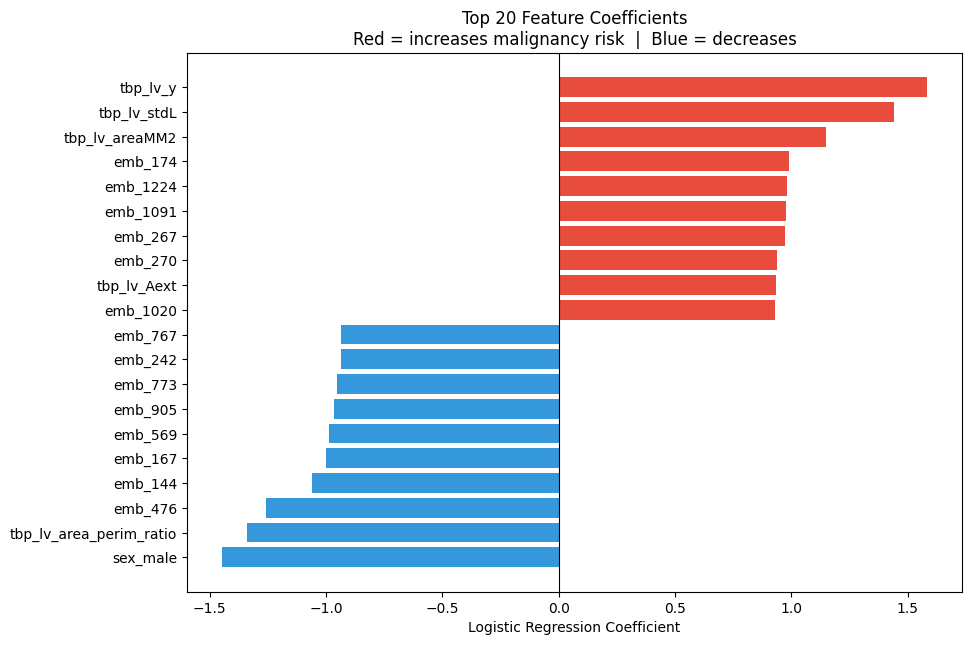

In [24]:
subset_tabular_w_cnn_logreg, subset_tabular_w_cnn_logreg_cv_results, num_cols, cat_cols, ysubset, ysubset_pred, ysubset_proba = run_log_reg(train_df)
feature_importance(subset_tabular_w_cnn_logreg, num_cols, cat_cols)


Saved: logreg_evaluation.png


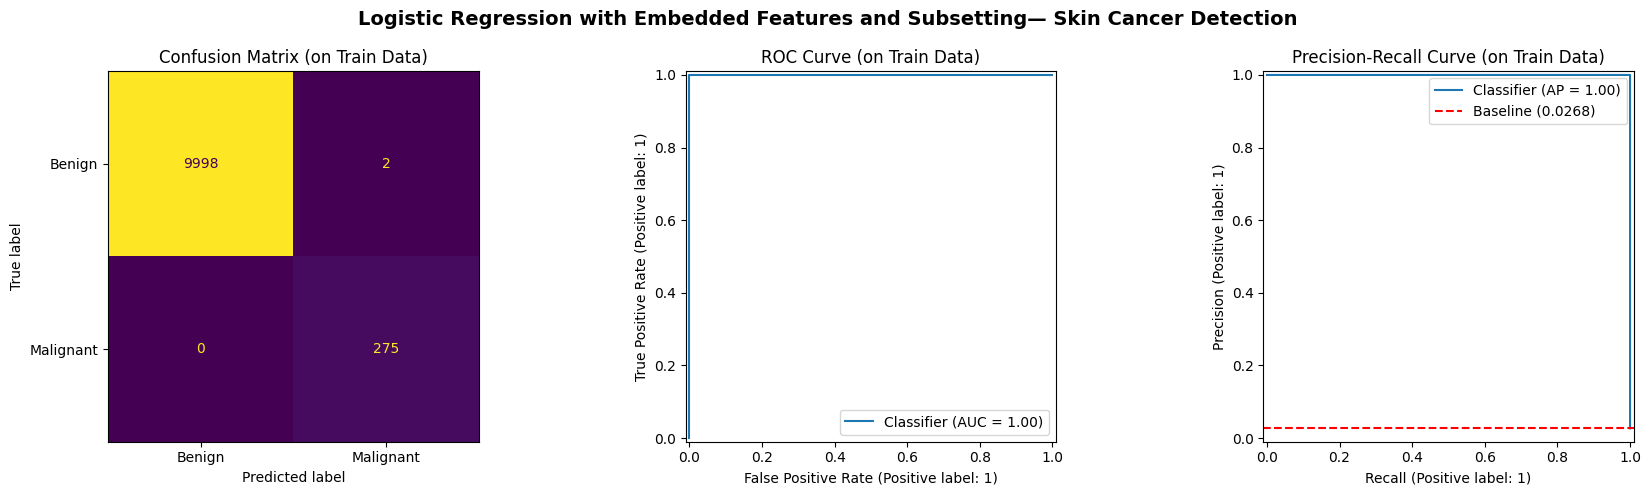

In [25]:
#visualizations on train

#plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Logistic Regression with Embedded Features and Subsetting— Skin Cancer Detection", fontsize=14, fontweight="bold")

#confusion matrix
cm = confusion_matrix(ysubset, ysubset_pred)
ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (on Train Data)")

#roc curve
RocCurveDisplay.from_predictions(ysubset, ysubset_proba, ax=axes[1])
axes[1].set_title("ROC Curve (on Train Data)")

#precision-recall
PrecisionRecallDisplay.from_predictions(ysubset, ysubset_proba, ax=axes[2])
baseline = ysubset.mean()
axes[2].axhline(baseline, color="red", linestyle="--", label=f"Baseline ({baseline:.4f})")
axes[2].legend()
axes[2].set_title("Precision-Recall Curve (on Train Data)")

plt.tight_layout()
plt.savefig("logreg_small_train_w_CNN_evaluation.png", dpi=150, bbox_inches="tight")
print("\nSaved: logreg_evaluation.png")


<h4 style = 'text-align: left;' >What We Can See So Far:</h4>

* **Full data; only tabular features:**
Better ROC-AUC (0.8928) but near-useless PR-AUC (0.0294)

* **Subsampled data; tabular + CNN features:** Lower ROC-AUC (0.7951) but dramatically better PR-AUC (0.2499)
  * the model is overfitting to the train data
  * there's no wrong malignant predictions on train, and only two wrong predictions on benign on train
  * additionally both the ROC-AUC curve and the PR-AUC curves are perfect

  <h4 style = 'text-align: left;' >How We Can Truly Check Performance:</h4>
  Let's bring the validation set in and see how the trained model is performing on it. We first need to do the same process again, subsampling validation (the same way we did train), extracting features and merging them with the small validation subset dataframe, then using our trained logreg model to make predictions and visualizing them. This should be more indicative of performance of our models


In [31]:
#predicting on val

#prepping val
leakage_cols = ["lesion_id", "iddx_full", "iddx_1", "iddx_2", "iddx_3", "iddx_4", "iddx_5",
                "mel_mitotic_index", "mel_thick_mm", "tbp_lv_dnn_lesion_confidence"]
admin_cols = ["isic_id", "patient_id", "attribution", "copyright_license", "image_type", "tbp_tile_type"]
drop_cols = [c for c in leakage_cols + admin_cols if c in val_df.columns]


#need to subset val too bc she'll also crash
benign_val = val_df[val_df['target'] == 0].sample(2000, random_state=42)
malignant_val = val_df[val_df['target'] == 1]  # keep all 59
val_small = pd.concat([benign_val, malignant_val]).reset_index(drop=True)

#first extract features
all_ids = val_small['isic_id'].tolist()
all_embeddings = []

with h5py.File(hdf5_path, 'r') as f:
  for i in tqdm(range(0, len(all_ids), batch_size), desc='Extracting val features'):
    batch_ids = all_ids[i : i + batch_size]
    tensors = []
    for isic_id in batch_ids:
      if isic_id in f:
        img = Image.open(io.BytesIO(f[isic_id][()])).convert('RGB')
        tensors.append(transform(img))
      else:
        tensors.append(torch.zeros(3, 224, 224))
    batch_tensor = torch.stack(tensors).to(device)
    with torch.no_grad():
      emb = backbone(batch_tensor).cpu().numpy()
    all_embeddings.append(emb)

all_embeddings = np.vstack(all_embeddings)

emb_cols = [f'emb_{i}' for i in range(1280)]
emb_df = pd.DataFrame(all_embeddings, columns=emb_cols)
emb_df.insert(0, 'isic_id', all_ids)

val_df_small= val_small.merge(emb_df, on='isic_id', how='left')

Extracting val features: 100%|██████████| 33/33 [00:14<00:00,  2.35it/s]


In [37]:
#save val to parquet (once is enough)
val_df_small.to_parquet('/content/drive/MyDrive/val_df_small_with_embeddings.parquet')


In [ ]:
#read it back
val_df_small = pd.read_parquet('/content/drive/MyDrive/val_df_small_with_embeddings.parquet')

In [34]:
#predicting on val
X_val = val_df_small.drop(columns=drop_cols + ['target'])
y_val = val_df_small['target']

y_val_proba = subset_tabular_w_cnn_logreg.predict_proba(X_val)[:, 1]
y_val_pred  = subset_tabular_w_cnn_logreg.predict(X_val)

#metrics on val
print(f"Val ROC-AUC : {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"Val PR-AUC  : {average_precision_score(y_val, y_val_proba):.4f}")
print(classification_report(y_val, y_val_pred, target_names=["Benign (0)", "Malignant (1)"]))

Val ROC-AUC : 0.8183
Val PR-AUC  : 0.2064
               precision    recall  f1-score   support

   Benign (0)       0.98      0.96      0.97      2000
Malignant (1)       0.24      0.39      0.29        59

     accuracy                           0.95      2059
    macro avg       0.61      0.68      0.63      2059
 weighted avg       0.96      0.95      0.95      2059




Saved: logreg_evaluation.png


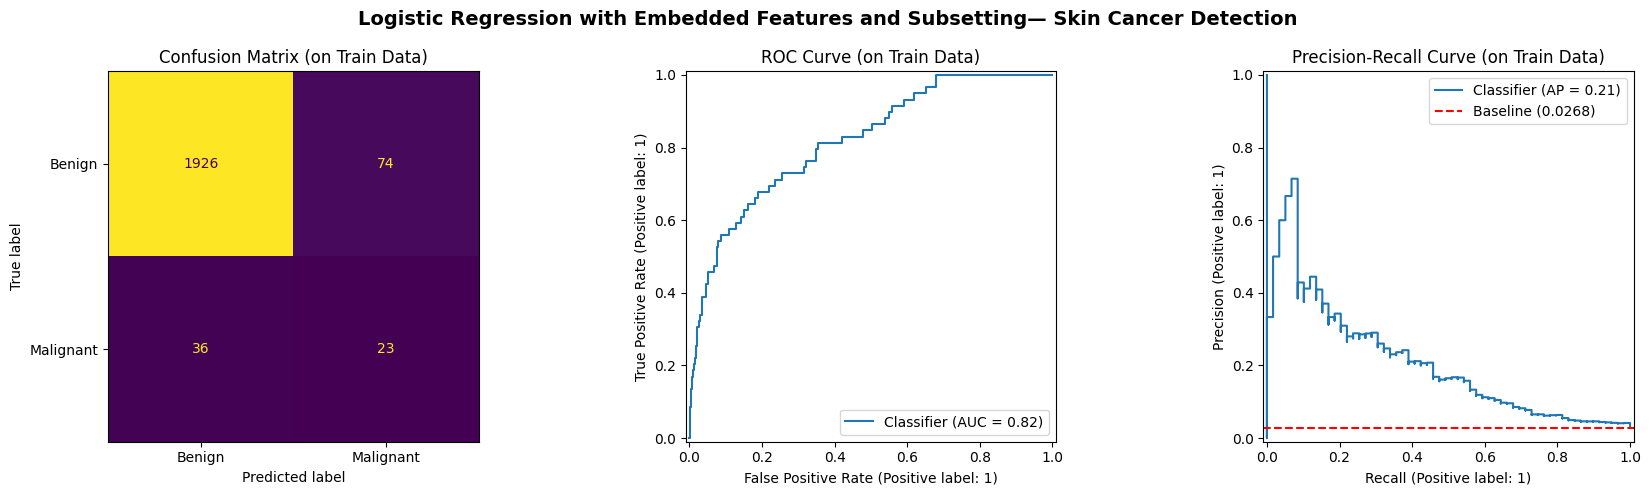

In [35]:
#visualizations on val

#plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Logistic Regression with Embedded Features and Subsetting— Skin Cancer Detection", fontsize=14, fontweight="bold")

#confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (on Train Data)")

#roc curve
RocCurveDisplay.from_predictions(y_val, y_val_proba, ax=axes[1])
axes[1].set_title("ROC Curve (on Train Data)")

#precision-recall
PrecisionRecallDisplay.from_predictions(y_val, y_val_proba, ax=axes[2])
baseline = ysubset.mean()
axes[2].axhline(baseline, color="red", linestyle="--", label=f"Baseline ({baseline:.4f})")
axes[2].legend()
axes[2].set_title("Precision-Recall Curve (on Train Data)")

plt.tight_layout()
plt.savefig("logreg_small_train_w_CNN_evaluation.png", dpi=150, bbox_inches="tight")
print("\nSaved: logreg_evaluation.png")


<h4 style = 'text-align: left;' >What Does This Mean?:</h4>

* We have a validation ROC-AUC of 0.81, and a validation PR-AUC of 0.2064, which is still an improvement from our baseline LogReg model
* We have 0.98 precision on benign cases and 0.24 precision on malignant cases
* We have 0.96 recall on benign cases and 0.39 recall on malignant cases
* This suggests that the logreg with extracted features is capturing *some* complexities of the data, likely because the CNN is now capturing intricacies of the lesions that were being missed by purely tabular data. However, the now included image features aren't enough to bypass LogReg's lack of fit for our data, leading to misclassifications still
* We have 36 malignant cases that were predicted as benign and 74 benign cases that were classified as malignant.

<h4 style = 'text-align: left;' >What Are Next Steps?:</h4>

* XGBoost on Tabular Data Only
* XGBoost on Full (or Subsetted) Embedded Data
* Combine XGBoost and LogReg to capture both nonlinear and linear patterns (ideally, this should perform the best)

<h3 style = 'text-align: left;'>XGBoost With Tabular Features Only</h3>

<h4 style = 'text-align: left;'>What is it?:</h4>

XGBoost is a stronger classifier that handles nonlinear relationships and feature interactions automatically. We could either just perform XGBoost's outputs to our different subsets of data, or we could stack XGBoost, having our different fitted LogReg models feed into the XGBoost. Here, XGBoost would be a meta-model, combining LogReg's output with the original features to make an even better final prediction.

Let's first try **XGBoost with just the tabular data**.

In [15]:
#getting the og version of our data back
train_data = pd.read_csv(f'{isic_2024_challenge_path}/train-metadata.csv')
test_data = pd.read_csv(f'{isic_2024_challenge_path}/test-metadata.csv')

#split off test first -- 30 test (will be split again into test and val) and 70 train
train_df, temp = train_test_split(
    train_data,
    test_size=0.30,
    stratify=train_data['target'],
    random_state=42
)

#then split test into val and test (15 each so 50 of the initial 30)
val_df, test_df = train_test_split(
    temp,
    test_size=0.50,
    stratify=temp['target'],
    random_state=42
)

#also make sure to do the same to train_images as well?
train_ids = train_df['isic_id'].tolist()
val_ids   = val_df['isic_id'].tolist()
test_ids  = test_df['isic_id'].tolist()

print(f"Train : {train_df.shape[0]} rows, {train_df['target'].sum()} malignant")
print(f"Val   : {val_df.shape[0]} rows, {val_df['target'].sum()} malignant")
print(f"Test  : {test_df.shape[0]} rows, {test_df['target'].sum()} malignant")

/tmp/ipykernel_27307/1522092447.py:2: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv(f'{isic_2024_challenge_path}/train-metadata.csv')


Train : 280741 rows, 275 malignant
Val   : 60159 rows, 59 malignant
Test  : 60159 rows, 59 malignant


In [41]:
train_df.head(2)

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
390115,ISIC_9724943,0,IP_7069393,60.0,male,anterior torso,3.58,TBP tile: close-up,3D: XP,21.045940,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,100.000000
382383,ISIC_9533808,0,IP_2248025,75.0,male,lower extremity,2.69,TBP tile: close-up,3D: white,18.877442,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,98.824513


In [29]:
#define xgboost function

import xgboost as xgb

def run_xgboost(df, val_df=None):

    leakage_cols = [
        "lesion_id",
        "iddx_full", "iddx_1", "iddx_2", "iddx_3", "iddx_4", "iddx_5",
        "mel_mitotic_index", "mel_thick_mm",
        "tbp_lv_dnn_lesion_confidence",
    ]
    admin_cols = [
        "isic_id", "patient_id",
        "attribution", "copyright_license",
        "image_type", "tbp_tile_type",
    ]

    target = "target"
    drop_cols = [c for c in leakage_cols + admin_cols if c in df.columns]
    feature_df = df.drop(columns=drop_cols + [target])

    cat_cols = [c for c in ["sex", "anatom_site_general",
                             "tbp_lv_location", "tbp_lv_location_simple"]
                if c in feature_df.columns]

    #XGBoost handles NaNs natively
    num_cols = feature_df.select_dtypes(include="number").columns.tolist()

    print(f"Numeric features   : {len(num_cols)}")
    print(f"Categorical features: {len(cat_cols)}")

    X = feature_df
    y = df[target]

    n_benign    = (y == 0).sum()
    n_malignant = (y == 1).sum()
    spw = n_benign / n_malignant
    print(f"scale_pos_weight   : {spw:.1f}  ({n_benign} benign / {n_malignant} malignant)")

    #numerics pass through
    #been need to preprocess categoricals with onehotencoder
    preprocessor = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols),
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", xgb.XGBClassifier(
            scale_pos_weight=spw,
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            eval_metric="aucpr",
            tree_method="hist",
            device="cuda",
            random_state=42,
            verbosity=0,
        )),
    ])

    #cross validation
    print("\nRunning 5-fold stratified cross-validation...")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_validate(
        model, X, y, cv=cv,
        scoring=["roc_auc", "average_precision", "f1"],
        return_train_score=False,
        n_jobs=1,
        verbose=1,
    )

    print("\n── Cross-Validation Results ──────────────────────────────────")
    for metric, key in [("ROC-AUC", "roc_auc"), ("PR-AUC", "average_precision"), ("F1", "f1")]:
        scores = cv_results[f"test_{key}"]
        print(f"  {metric:<22}: {scores.mean():.4f} ± {scores.std():.4f}  {np.round(scores, 4)}")

    #fit final model
    print("\nFitting final model on full training data...")
    model.fit(X, y)

    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    print("\n── Training Set Metrics ──────────────────────────────────────")
    print(f"  ROC-AUC : {roc_auc_score(y, y_proba):.4f}")
    print(f"  PR-AUC  : {average_precision_score(y, y_proba):.4f}")
    print(classification_report(y, y_pred, target_names=["Benign (0)", "Malignant (1)"]))

  #and let's just calc on validation in here itself
    if val_df is not None:
        X_val = val_df.drop(columns=[c for c in drop_cols + [target]
                                     if c in val_df.columns])
        y_val = val_df[target]
        y_val_proba = model.predict_proba(X_val)[:, 1]
        y_val_pred  = model.predict(X_val)

        print("\n── Validation Set Metrics ────────────────────────────────────")
        print(f"  ROC-AUC : {roc_auc_score(y_val, y_val_proba):.4f}")
        print(f"  PR-AUC  : {average_precision_score(y_val, y_val_proba):.4f}")
        print(classification_report(y_val, y_val_pred,
                                    target_names=["Benign (0)", "Malignant (1)"]))

    #and plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("XGBoost — Tabular and Embedded, Full Train Split", fontsize=14, fontweight="bold")

    ConfusionMatrixDisplay(confusion_matrix(y, y_pred),
                           display_labels=["Benign", "Malignant"]).plot(ax=axes[0], colorbar=False)
    axes[0].set_title("Confusion Matrix (Train)")

    RocCurveDisplay.from_predictions(y, y_proba, ax=axes[1])
    axes[1].set_title("ROC Curve (Train)")

    PrecisionRecallDisplay.from_predictions(y, y_proba, ax=axes[2])
    axes[2].axhline(y.mean(), color="red", linestyle="--", label=f"Baseline ({y.mean():.4f})")
    axes[2].legend()
    axes[2].set_title("Precision-Recall Curve (Train)")

    plt.tight_layout()
    plt.savefig("xgb_tabular_evaluation.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: xgb_tabular_evaluation.png")

    #and plot val
    if val_df is not None:
      fig, axes = plt.subplots(1, 3, figsize=(18, 5))
      fig.suptitle("XGBoost — Tabular and Embedded, Validation Split", fontsize=14, fontweight="bold")

      ConfusionMatrixDisplay(confusion_matrix(y_val, y_val_pred),
                            display_labels=["Benign", "Malignant"]).plot(ax=axes[0], colorbar=False)
      axes[0].set_title("Confusion Matrix (Validation)")

      RocCurveDisplay.from_predictions(y_val, y_val_proba, ax=axes[1])
      axes[1].set_title("ROC Curve (Validation)")

      PrecisionRecallDisplay.from_predictions(y_val, y_val_proba, ax=axes[2])
      axes[2].axhline(y.mean(), color="red", linestyle="--", label=f"Baseline ({y.mean():.4f})")
      axes[2].legend()
      axes[2].set_title("Precision-Recall Curve (Validation)")

      plt.tight_layout()
      plt.savefig("xgb_tabular_evaluation.png", dpi=150, bbox_inches="tight")
      plt.show()
      print("Saved: xgb_tabular_evaluation.png")

    #and do feature importance
    ohe_features = (
        model.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .named_steps["ohe"]
        .get_feature_names_out(cat_cols)
        .tolist()
    )
    all_features = num_cols + ohe_features
    imp_df = pd.DataFrame({
        "feature": all_features,
        "importance": model.named_steps["clf"].feature_importances_,
    }).sort_values("importance", ascending=False)

    print("\n── Top 20 Features by Importance ─────────────────────────────")
    print(imp_df.head(20).to_string(index=False))

    return model, cv_results



Numeric features   : 34
Categorical features: 4
scale_pos_weight   : 1019.9  (280466 benign / 275 malignant)

Running 5-fold stratified cross-validation...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   48.0s finished



── Cross-Validation Results ──────────────────────────────────
  ROC-AUC               : 0.9237 ± 0.0076  [0.9214 0.9254 0.9284 0.9327 0.9104]
  PR-AUC                : 0.0594 ± 0.0209  [0.0603 0.0885 0.0496 0.072  0.0266]
  F1                    : 0.0834 ± 0.0284  [0.0526 0.1304 0.1    0.0723 0.0619]

Fitting final model on full training data...

── Training Set Metrics ──────────────────────────────────────
  ROC-AUC : 1.0000
  PR-AUC  : 1.0000
               precision    recall  f1-score   support

   Benign (0)       1.00      1.00      1.00    280466
Malignant (1)       0.75      1.00      0.86       275

     accuracy                           1.00    280741
    macro avg       0.88      1.00      0.93    280741
 weighted avg       1.00      1.00      1.00    280741


── Validation Set Metrics ────────────────────────────────────
  ROC-AUC : 0.9202
  PR-AUC  : 0.0475
               precision    recall  f1-score   support

   Benign (0)       1.00      1.00      1.00     60100
Ma

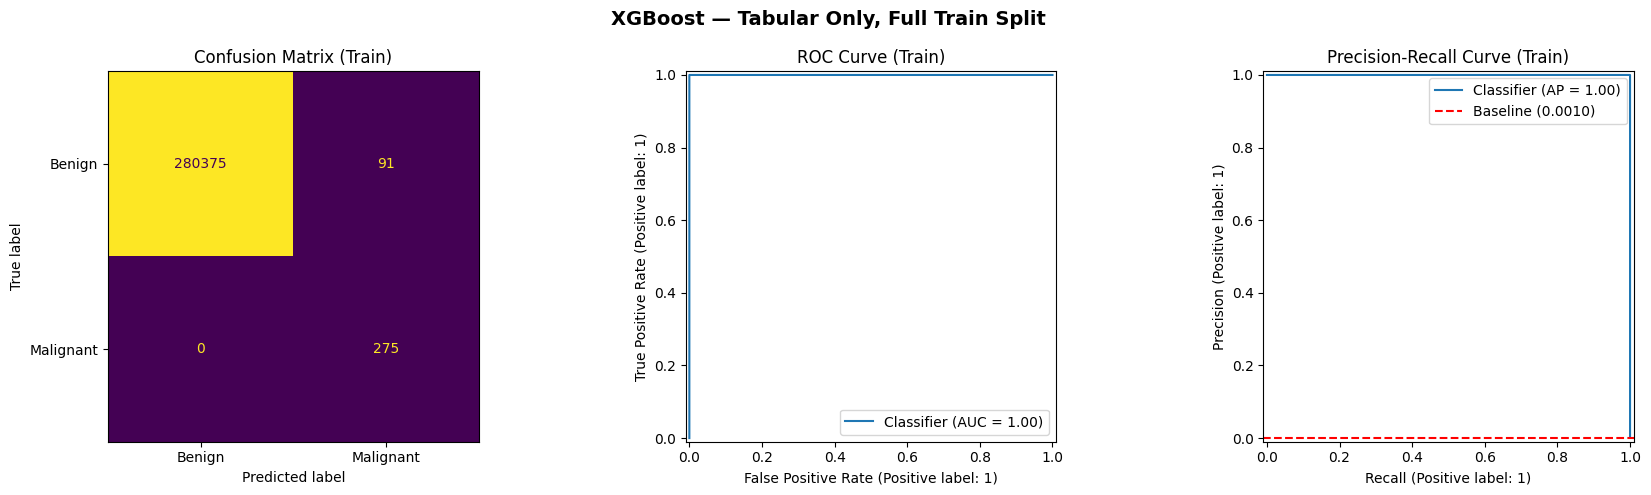

Saved: xgb_tabular_evaluation.png


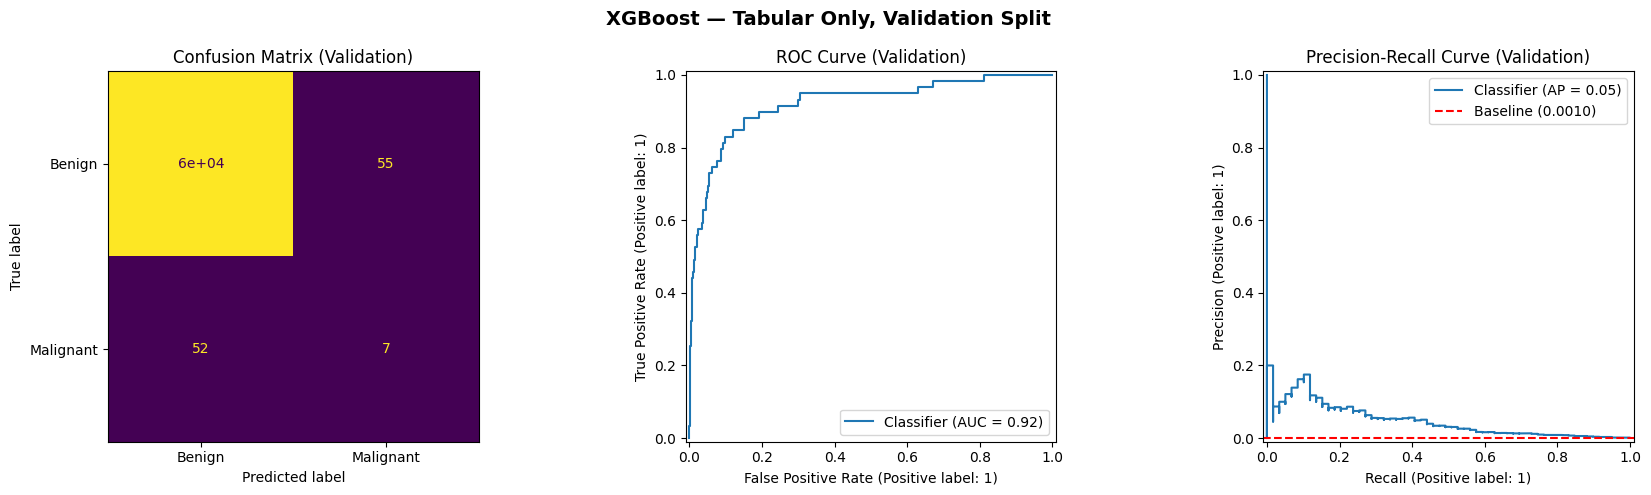

Saved: xgb_tabular_evaluation.png

── Top 20 Features by Importance ─────────────────────────────
                          feature  importance
      tbp_lv_location_Head & Neck    0.106868
                         tbp_lv_H    0.072607
         tbp_lv_location_Left Leg    0.065645
           clin_size_long_diam_mm    0.060930
    anatom_site_general_head/neck    0.052043
                tbp_lv_norm_color    0.043061
               tbp_lv_minorAxisMM    0.036568
 tbp_lv_location_Left Arm - Lower    0.034879
                   tbp_lv_areaMM2    0.032088
      tbp_lv_radial_color_std_max    0.028641
               tbp_lv_deltaLBnorm    0.026040
               tbp_lv_perimeterMM    0.022216
tbp_lv_location_Right Arm - Lower    0.020456
                         tbp_lv_y    0.016106
                         sex_male    0.015315
                      tbp_lv_Hext    0.013192
                       sex_female    0.013188
            tbp_lv_color_std_mean    0.012552
                   tbp_lv_de

In [48]:
#let's call this bad boy
model_xgb, cv_results_xgb = run_xgboost(train_df, val_df=val_df)


<h4 style = 'text-align: left;'>Main Takeaways</h4>

* Cross-Val ROC-AUC of 0.9237
* Cross-Val PR-AUC of 0.0594
* Validation ROC-AUC of 0.9202
* Validation PR-AUC of 0.0475

<h4 style = 'text-align: left;'>What Does This Mean?</h4>

* Overfitting to the train data (present before as well)
* Purely tabular features aren't enough to ensure high precision on the validation set
* Need some image feature information

<h4 style = 'text-align: left;'>Next Steps</h4>

Let's run just XGBoost on Embedded data, first trying the full set then trying the subset if needed

UPDATE: full set, didn't work, we're using subset instead

<h3 style = 'text-align: left;'>XGBoost With Tabular and Embedded Features (Subset)</h3>



In [2]:
#i keep crashing so putting these here also so i don't have to keep scrolling

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os #for loading in data
import h5py #for reading image data in .hdf5 format
import matplotlib.pyplot as plt #for plotting purposes
from PIL import Image #for visualizing image data
import io #also for image data
import seaborn as sns #for plotting purposes as well
from sklearn.linear_model import LogisticRegression #for logreg
from sklearn.model_selection import StratifiedKFold, cross_validate #for cross val
from sklearn.pipeline import Pipeline #for pipeline implementation
from sklearn.preprocessing import StandardScaler #for standard scaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder #for one hot encoding
from sklearn.metrics import ( #for performance metrics
    classification_report, roc_auc_score, confusion_matrix,
    average_precision_score, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay)
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.model_selection import train_test_split #to split train into train, val, test

#mounting so i can reead from drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#load in the right data

train_small_embeddings = pd.read_parquet('/content/drive/MyDrive/train_df_small_with_embeddings.parquet')
val_small_embeddings = pd.read_parquet('/content/drive/MyDrive/val_df_small_with_embeddings.parquet')

Numeric features   : 1314
Categorical features: 4
scale_pos_weight   : 36.4  (10000 benign / 275 malignant)

Running 5-fold stratified cross-validation...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.1min finished



── Cross-Validation Results ──────────────────────────────────
  ROC-AUC               : 0.9414 ± 0.0052  [0.9397 0.9467 0.9478 0.9393 0.9337]
  PR-AUC                : 0.5369 ± 0.0374  [0.5398 0.573  0.5639 0.5412 0.4668]
  F1                    : 0.4657 ± 0.0279  [0.4731 0.4938 0.4667 0.4819 0.413 ]

Fitting final model on full training data...

── Training Set Metrics ──────────────────────────────────────
  ROC-AUC : 1.0000
  PR-AUC  : 1.0000
               precision    recall  f1-score   support

   Benign (0)       1.00      1.00      1.00     10000
Malignant (1)       1.00      1.00      1.00       275

     accuracy                           1.00     10275
    macro avg       1.00      1.00      1.00     10275
 weighted avg       1.00      1.00      1.00     10275


── Validation Set Metrics ────────────────────────────────────
  ROC-AUC : 0.9485
  PR-AUC  : 0.5515
               precision    recall  f1-score   support

   Benign (0)       0.98      1.00      0.99      2000
Ma

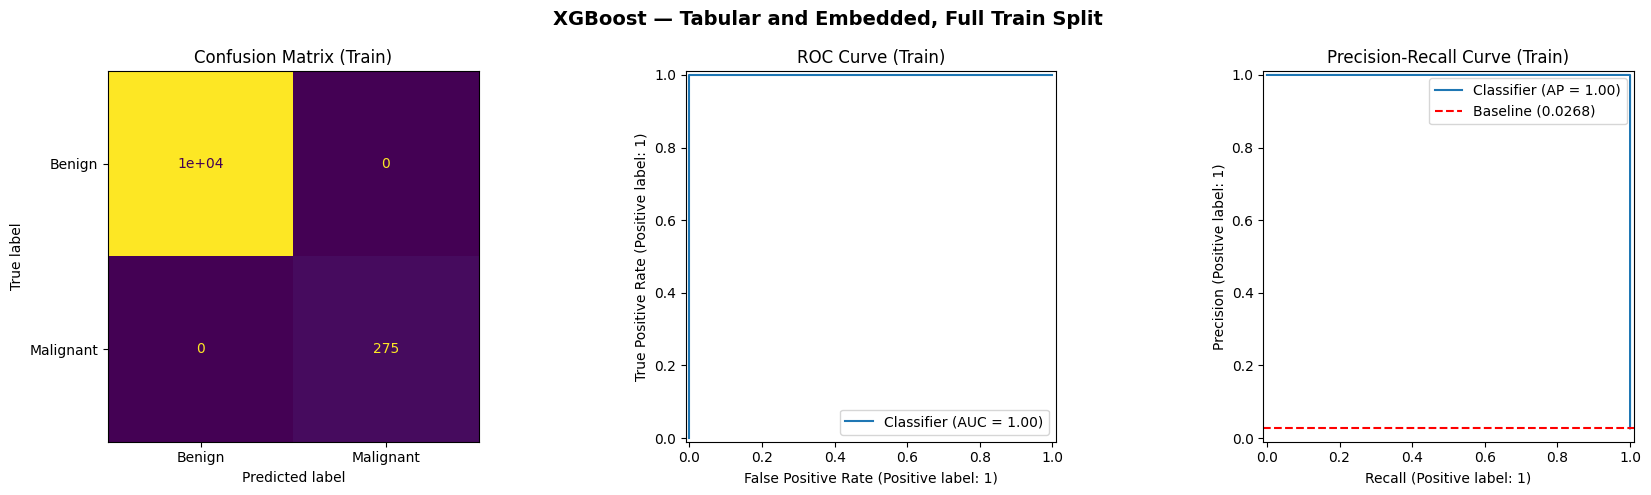

Saved: xgb_tabular_evaluation.png


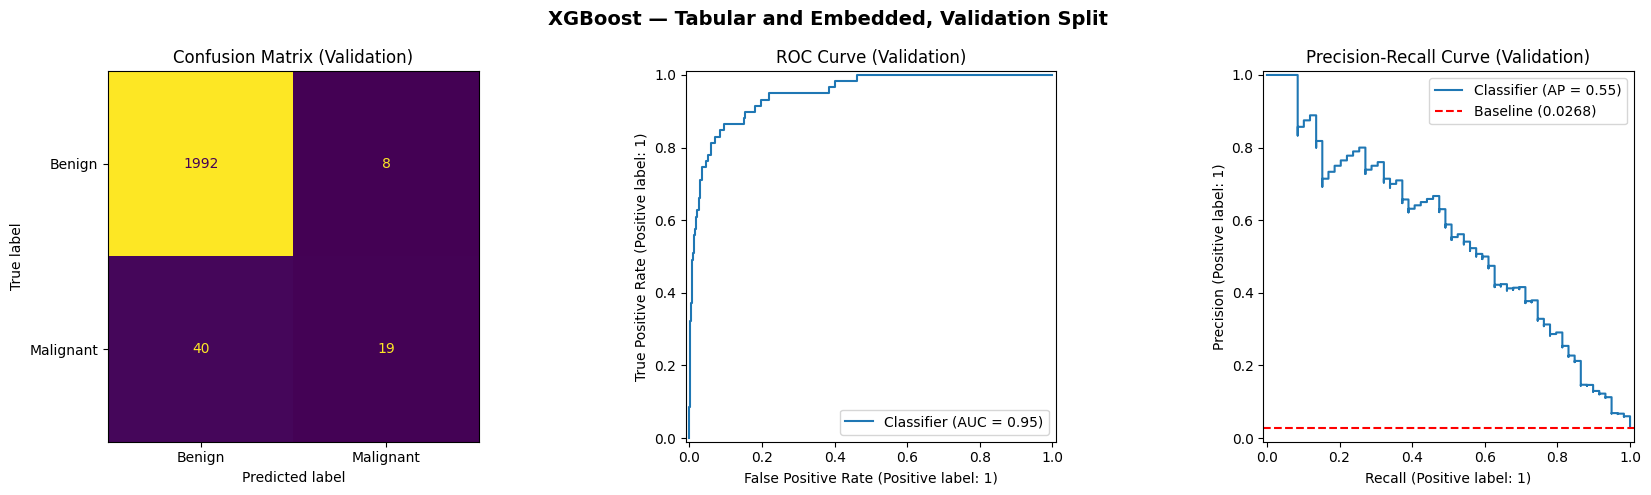

Saved: xgb_tabular_evaluation.png

── Top 20 Features by Importance ─────────────────────────────
                            feature  importance
                           tbp_lv_H    0.012232
                           emb_1073    0.011850
                  tbp_lv_norm_color    0.010544
        tbp_lv_location_Head & Neck    0.010330
      anatom_site_general_head/neck    0.009217
                 tbp_lv_minorAxisMM    0.008119
             clin_size_long_diam_mm    0.006663
                 tbp_lv_perimeterMM    0.006633
                            emb_721    0.006611
                     tbp_lv_areaMM2    0.006513
                           emb_1215    0.006422
                      tbp_lv_deltaB    0.005959
                            emb_604    0.005595
                            emb_808    0.005595
                           emb_1169    0.005476
                            emb_884    0.005012
                           emb_1054    0.004941
anatom_site_general_lower extremity   

In [30]:
#cross your fingers cross your toes
small_embeds_model_xgb, small_embeds_cv_results_xgb = run_xgboost(train_small_embeddings, val_small_embeddings)


<h4 style = 'text-align: left;'>Main Takeaways</h4>

* Cross-Val ROC-AUC of 0.9414
* Cross-Val PR-AUC of 0.5369
* Validation ROC-AUC of 0.9485
* Validation PR-AUC of 0.5515

<h4 style = 'text-align: left;'>What Does This Mean?</h4>

* Using just the XGBoost trained on the subset of train data with embedded features performs MUCH BETTER than purely tabular features AND LogReg trained with embedded features
* Purely tabular features aren't enough to ensure high precision on the validation set
* As expected, image features provide necessary input
* However, our class imbalance is coming into play again. We're predicting almost every single benign case correctly but predicting incorrectly on about 32.20% of malignant cases, which is still a high rate of error on malignant cases

<h4 style = 'text-align: left;'>Next Steps</h4>

Let's now run a stacked model

<h3 style = 'text-align: left;'>Stacking XGBoost with LogReg</h3>

We first generate out of fold predictions from all base models (I believe with LogReg) then use XGBoost on these results

In [16]:
#we need train_df, and train_small_embeddings

#getting the og version of our data back
train_data = pd.read_csv(f'{isic_2024_challenge_path}/train-metadata.csv')
test_data = pd.read_csv(f'{isic_2024_challenge_path}/test-metadata.csv')

#split off test first -- 30 test (will be split again into test and val) and 70 train
train_df, temp = train_test_split(
    train_data,
    test_size=0.30,
    stratify=train_data['target'],
    random_state=42
)

#then split test into val and test (15 each so 50 of the initial 30)
val_df, test_df = train_test_split(
    temp,
    test_size=0.50,
    stratify=temp['target'],
    random_state=42
)

#also make sure to do the same to train_images as well?
train_ids = train_df['isic_id'].tolist()
val_ids   = val_df['isic_id'].tolist()
test_ids  = test_df['isic_id'].tolist()



/tmp/ipykernel_27307/2145134571.py:4: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv(f'{isic_2024_challenge_path}/train-metadata.csv')


In [17]:
#putting together everything we've done so far

LEAKAGE_COLS = ["lesion_id", "iddx_full", "iddx_1", "iddx_2", "iddx_3",
                "iddx_4", "iddx_5", "mel_mitotic_index", "mel_thick_mm",
                "tbp_lv_dnn_lesion_confidence"]
ADMIN_COLS   = ["isic_id", "patient_id", "attribution", "copyright_license",
                "image_type", "tbp_tile_type"]
CAT_COLS     = ["sex", "anatom_site_general", "tbp_lv_location", "tbp_lv_location_simple"]
TARGET       = "target"

def get_X_y(df):
    """Drop leakage/admin cols and return X, y."""
    drop = [c for c in LEAKAGE_COLS + ADMIN_COLS if c in df.columns]
    feature_df = df.drop(columns=drop + [TARGET])
    cat_cols = [c for c in CAT_COLS if c in feature_df.columns]
    num_cols = feature_df.select_dtypes(include="number").columns.tolist()
    return feature_df, df[TARGET], num_cols, cat_cols

def make_logreg_pipeline(num_cols, cat_cols, spw):
    return Pipeline([
        ("pre", ColumnTransformer([
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("scl", StandardScaler())]), num_cols),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                              ("ohe", OneHotEncoder(handle_unknown="ignore",
                                                    sparse_output=False))]), cat_cols),
        ])),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000,
                                   solver="lbfgs", C=1.0, random_state=42)),
    ])

def make_xgb_pipeline(num_cols, cat_cols, spw):
    return Pipeline([
        ("pre", ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), num_cols),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                              ("ohe", OneHotEncoder(handle_unknown="ignore",
                                                    sparse_output=False))]), cat_cols),
        ])),
        ("clf", xgb.XGBClassifier(
            scale_pos_weight=spw, n_estimators=500, learning_rate=0.05,
            max_depth=6, subsample=0.8, colsample_bytree=0.8,
            min_child_weight=5, eval_metric="aucpr",
            tree_method="hist", device="cuda",
            random_state=42, verbosity=0,
        )),
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [20]:
print("Generating out-of-fold predictions for base models...")

#1: LogReg, tabular only (full data)
print("\n[1/4] LogReg — tabular only")
X1, y1, num1, cat1 = get_X_y(train_df)
spw1 = (y1 == 0).sum() / (y1 == 1).sum()
pipe1 = make_logreg_pipeline(num1, cat1, spw1)
oof1 = cross_val_predict(pipe1, X1, y1, cv=cv, method="predict_proba")[:, 1]
pipe1.fit(X1, y1)
print(f"  OOF ROC-AUC: {roc_auc_score(y1, oof1):.4f}")

#2: XGBoost, tabular only (full data)
print("\n[2/4] XGBoost — tabular only")
X2, y2, num2, cat2 = get_X_y(train_df)
spw2 = (y2 == 0).sum() / (y2 == 1).sum()
pipe2 = make_xgb_pipeline(num2, cat2, spw2)
oof2 = cross_val_predict(pipe2, X2, y2, cv=cv, method="predict_proba")[:, 1]
pipe2.fit(X2, y2)
print(f"  OOF ROC-AUC: {roc_auc_score(y2, oof2):.4f}")

#3: LogReg, tabular and CNN (small data)
print("\n[3/4] LogReg — tabular + CNN embeddings (subsampled)")
X3, y3, num3, cat3 = get_X_y(train_small_embeddings)
spw3 = (y3 == 0).sum() / (y3 == 1).sum()
pipe3 = make_logreg_pipeline(num3, cat3, spw3)
oof3 = cross_val_predict(pipe3, X3, y3, cv=cv, method="predict_proba")[:, 1]
pipe3.fit(X3, y3)
print(f"  OOF ROC-AUC: {roc_auc_score(y3, oof3):.4f}")

#4: XGBoost, tabular and CNN (small data)
print("\n[4/4] XGBoost — tabular + CNN embeddings (subsampled)")
X4, y4, num4, cat4 = get_X_y(train_small_embeddings)
spw4 = (y4 == 0).sum() / (y4 == 1).sum()
pipe4 = make_xgb_pipeline(num4, cat4, spw4)
oof4 = cross_val_predict(pipe4, X4, y4, cv=cv, method="predict_proba")[:, 1]
pipe4.fit(X4, y4)
print(f"  OOF ROC-AUC: {roc_auc_score(y4, oof4):.4f}")


Generating out-of-fold predictions for base models...

[1/4] LogReg — tabular only
  OOF ROC-AUC: 0.8921

[2/4] XGBoost — tabular only
  OOF ROC-AUC: 0.9231

[3/4] LogReg — tabular + CNN embeddings (subsampled)
  OOF ROC-AUC: 0.7948

[4/4] XGBoost — tabular + CNN embeddings (subsampled)
  OOF ROC-AUC: 0.9413


In [22]:
#build meta model features from existing variables
meta_train_full = pd.DataFrame({
    "logreg_tab": oof1,
    "xgb_tab":    oof2,
}, index=train_df.index)

meta_train_small = pd.DataFrame({
    "logreg_cnn": oof3,
    "xgb_cnn":    oof4,
}, index=train_small_embeddings.index)

meta_train = meta_train_full.join(meta_train_small, how="left")
y_meta = train_df[TARGET]

In [23]:
#train xgboost meta model

spw_meta = (y_meta == 0).sum() / (y_meta == 1).sum()

meta_model = Pipeline([
    ("imp", SimpleImputer(strategy="median")),  # handles NaN CNN cols
    ("clf", xgb.XGBClassifier(
        scale_pos_weight=spw_meta,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,          # shallow — only 4 input features
        subsample=0.8,
        eval_metric="aucpr",
        tree_method="hist",
        device="cuda",
        random_state=42,
        verbosity=0,
    )),
])

#cross val on meta model
oof_meta = cross_val_predict(meta_model, meta_train, y_meta,
                              cv=cv, method="predict_proba")[:, 1]
print(f"\n── Stacked Model OOF Metrics ─────────────────────────────────")
print(f"  ROC-AUC : {roc_auc_score(y_meta, oof_meta):.4f}")
print(f"  PR-AUC  : {average_precision_score(y_meta, oof_meta):.4f}")

meta_model.fit(meta_train, y_meta)



── Stacked Model OOF Metrics ─────────────────────────────────
  ROC-AUC : 0.9223
  PR-AUC  : 0.0397


Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='aucpr',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [26]:
print("\nEvaluating stacked model on validation set...")

# get base model predictions on val
X_val1, y_val, _, _ = get_X_y(val_df)
X_val3, _, _, _     = get_X_y(val_small_embeddings)   # val with CNN embeddings

meta_val = pd.DataFrame({
    "logreg_tab":  pipe1.predict_proba(X_val1)[:, 1],
    "xgb_tab":     pipe2.predict_proba(X_val1)[:, 1],
}, index=val_df.index)

# CNN val predictions — only for rows in val_small
cnn_val_preds = pd.DataFrame({
    "logreg_cnn": pipe3.predict_proba(X_val3)[:, 1],
    "xgb_cnn":    pipe4.predict_proba(X_val3)[:, 1],
}, index=val_small_embeddings.index)

meta_val = meta_val.join(cnn_val_preds, how="left")

y_val_proba = meta_model.predict_proba(meta_val)[:, 1]
y_val_pred  = meta_model.predict(meta_val)

print(f"\n── Validation Set Metrics ────────────────────────────────────")
print(f"  ROC-AUC : {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"  PR-AUC  : {average_precision_score(y_val, y_val_proba):.4f}")
print(classification_report(y_val, y_val_pred,
                             target_names=["Benign (0)", "Malignant (1)"]))


Evaluating stacked model on validation set...

── Validation Set Metrics ────────────────────────────────────
  ROC-AUC : 0.9222
  PR-AUC  : 0.0433
               precision    recall  f1-score   support

   Benign (0)       1.00      0.89      0.94     60100
Malignant (1)       0.01      0.83      0.01        59

     accuracy                           0.89     60159
    macro avg       0.50      0.86      0.48     60159
 weighted avg       1.00      0.89      0.94     60159



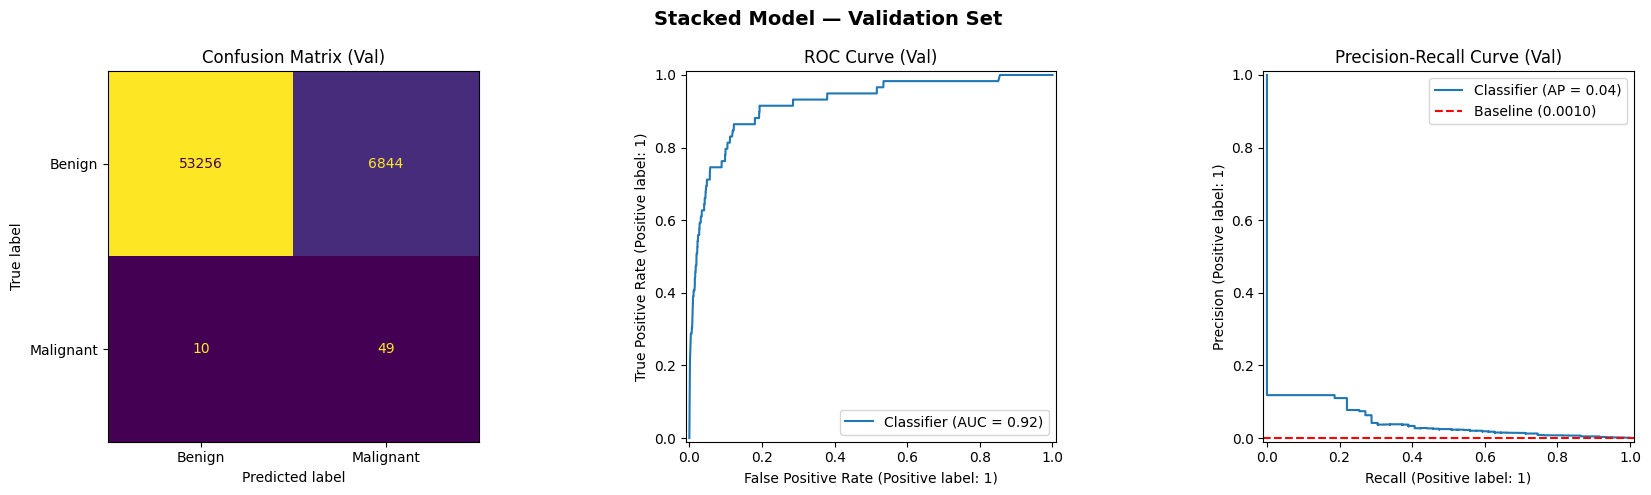

Saved: stacked_val_evaluation.png


In [27]:
#plotting

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Stacked Model — Validation Set", fontsize=14, fontweight="bold")

ConfusionMatrixDisplay(confusion_matrix(y_val, y_val_pred),
                       display_labels=["Benign", "Malignant"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (Val)")

RocCurveDisplay.from_predictions(y_val, y_val_proba, ax=axes[1])
axes[1].set_title("ROC Curve (Val)")

PrecisionRecallDisplay.from_predictions(y_val, y_val_proba, ax=axes[2])
axes[2].axhline(y_val.mean(), color="red", linestyle="--",
                label=f"Baseline ({y_val.mean():.4f})")
axes[2].legend()
axes[2].set_title("Precision-Recall Curve (Val)")

plt.tight_layout()
plt.savefig("stacked_val_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: stacked_val_evaluation.png")

<h4 style = 'text-align: left;'>Main Takeaways</h4>

* LogReg (tabular only) OOF ROC-AUC of 0.8921
* XGBoost (tabular only) OOF ROC-AUC of 0.9231
* LogReg (tabular and CNN embeddings with subsample) OOF ROC-AUC of 0.7948
* XGBoost (tabular + CNN embeddings subsample) OOF ROC-AUC of 0.9413
* Validation ROC-AUC of 0.9222
* Validation PR-AUC of 0.0433

* **REMEMBER**
  * Precision: Of all cases that were classified as malignant, how many actually are?
  * Recall: Of all malignant cases, how many were classified correctly?
  * Low precision isn't necessarily a bad thing. It's looking at all the cases classified as malignant, and our high class imbalance can often warp this value because many of the malignant classifications done by the model are actually benign
  * It's looking at the confusion matrix that can clear this up:
  * We have a recall of 49/(10 + 49) = 83.05% in malignant cases with this model
  * And a recall of 53256/(53256 + 6844) = 88.61% in benign cases with this model
  * This is the best achieved out of all the model's I've tried thus far


